### GraphSAGE: Iductive Representation Learning on Large Graphs

Telecom Recommendation System

1. Data Preprocessing
2. Building the Graph
3. Train GraphSAGE
3. Evaulation
4. Inference

* [Paper](https://arxiv.org/pdf/1706.02216)

In [1]:
import pandas as pd
import numpy as np
import random 
from pyspark.sql import SparkSession, Row, DataFrame
from pyspark.sql import functions as Fp
from pyspark.sql.types import StructType, StructField, DoubleType
import re
from typing import Dict, Optional, Any

import torch
import os
import gc
import glob
import math
import random
from pathlib import Path

import duckdb
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import roc_auc_score, average_precision_score

from torch_geometric.data import HeteroData
from torch_geometric.loader import LinkNeighborLoader
from torch_geometric.nn import HeteroConv, SAGEConv
from torch_geometric.seed import seed_everything


import warnings
warnings.filterwarnings('ignore', message='.*Cannot infer the eval type.*')

In [2]:
def seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed(43)

In [3]:
# init spark
APP_NAME: str = "GraphSAGE_SPARK"

spark = SparkSession\
    .builder\
    .appName(APP_NAME)\
    .config("spark.driver.extraJavaOptions", "-Djava.security.manager=allow")\
    .config("spark.executor.extraJavaOptions", "-Djava.security.manager=allow")\
    .master("local[*]")\
    .config("spark.driver.memory", "16g")\
    .getOrCreate()

spark

In [4]:
DATA_FOLDER: str = r"../../datasets/daily subscriptions"
DAILY_M8: str = rf"{DATA_FOLDER}/daily_sub_202508_with_locations_mobiles.csv"
DAILY_M9: str = rf"{DATA_FOLDER}/daily_sub_202509_with_locations_mobiles.csv"
DAILY_M10: str = rf"{DATA_FOLDER}/daily_sub_202510_with_locations_mobiles.csv"

paths = [DAILY_M8, DAILY_M9, DAILY_M10]

BAD_VALUES = ["NULL", "null", "", "N/A", "NA", "None"]
KDO_CANAL = "KDO"
OUT_OF_REC = [ ] # bundles should not enter the recommendation model.

In [5]:
COLs = ["tbl_dt", "msisdn", "bundle_id", "bundle_name", "bundle_type", "validity", 
        "price", "configured_volume", "usage_type",  
        "subscriptions", "total_rev", "service_class_category",
        "canal", "payment_mode", "department_city",
        "brand_name", "device_capability"]

data = (
    spark.read
    .csv(paths, header=True, inferSchema=True)
    .select(COLs)
)

total_count = data.count()
total_count

117584260

In [6]:
data.show(10, 0)

+--------+------------+-----------+--------------------------------------------------+------------+--------+-----+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+
|tbl_dt  |msisdn      |bundle_id  |bundle_name                                       |bundle_type |validity|price|configured_volume|usage_type|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name             |device_capability|
+--------+------------+-----------+--------------------------------------------------+------------+--------+-----+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+
|20250809|242069835561|SMSPK50    |SMS Bundle 2 Days @66F                            |BUNDLE_SMS  |2 Days  |66F  |null             |CHARGED   |1            |66.0     |PREPAID               |ECW  |

In [7]:
data.dtypes

[('tbl_dt', 'int'),
 ('msisdn', 'bigint'),
 ('bundle_id', 'string'),
 ('bundle_name', 'string'),
 ('bundle_type', 'string'),
 ('validity', 'string'),
 ('price', 'string'),
 ('configured_volume', 'string'),
 ('usage_type', 'string'),
 ('subscriptions', 'int'),
 ('total_rev', 'double'),
 ('service_class_category', 'string'),
 ('canal', 'string'),
 ('payment_mode', 'string'),
 ('department_city', 'string'),
 ('brand_name', 'string'),
 ('device_capability', 'string')]

In [8]:
# Remove VAS interactions because most VAS bundles have missing all critical features 
# (price, validity, configured_volume, ..etc.)., which can introduce can harm GraphSAGE recommendation quality
data = data.filter(
    Fp.col("bundle_type") != "VAS"
)
data.count() 

109466204

In [9]:
# Number of Nulls and BAD_VALUES in the data.
def nulls(data):
    exprs = []
    df = data.select([Fp.col(c).cast("string").alias(c) for c in data.columns])

    for c in df.columns:
        exprs.append(
            Fp.sum(
                Fp.when(
                    Fp.col(c).isNull() | Fp.col(c).isin(BAD_VALUES) | (Fp.trim(Fp.col(c)) == ""),
                    1
                ).otherwise(0)
            ).alias(c)
        )

    null_profile = df.select(exprs)
    print(null_profile.show(100, 0))

nulls(data)

+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price   |configured_volume|usage_type|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|0     |0     |7905     |7916       |7916       |23158499|23158277|42985009         |7916      |0            |0        |3076                  |0    |0           |14706898       |22632     |11               |
+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+------

In [10]:
df_filtered = data.filter(
    Fp.trim(Fp.col("bundle_id")).isNull() |
    (Fp.trim(Fp.col("bundle_id")) == "") |
    (Fp.col("bundle_id") == "NULL") |
    Fp.trim(Fp.col("bundle_name")).isNull() |
    (Fp.trim(Fp.col("bundle_name")) == "") |
    (Fp.col("bundle_name") == "NULL")
)

df_filtered.show(20, 0)

+------+------+---------+-----------+-----------+--------+-----+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price|configured_volume|usage_type|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+-----+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
+------+------+---------+-----------+-----------+--------+-----+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+



## Data Prepreocessing

In [11]:
# Handling Null Values
# remove any row when its Bundle_id/Bundle_name is Null or it is in BAD_VALUES
data = data.filter(
    ~Fp.col("bundle_id").isin(BAD_VALUES) &
    ~Fp.col("bundle_name").isin(BAD_VALUES) &
    Fp.col("bundle_id").isNotNull() &
    Fp.col("bundle_name").isNotNull() &
    (Fp.trim(Fp.col("bundle_id")) != "") &
    (Fp.trim(Fp.col("bundle_name")) != "")
)

print(f"data count atfer removing null values in bunlde_id/bundle_name: {data.count()}")
print(f"Removed: {(((total_count - data.count())/ total_count) * 100)}% of data")

data count atfer removing null values in bunlde_id/bundle_name: 109458288
Removed: 6.910765097301288% of data


In [12]:
nulls(data)

+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price   |configured_volume|usage_type|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|0     |0     |0        |0          |0          |23150583|23150361|42977093         |0         |0            |0        |3075                  |0    |0           |14698985       |22628     |11               |
+------+------+---------+-----------+-----------+--------+--------+-----------------+----------+-------------+---------+----------------------+-----+------------+------

In [13]:
def value_counts(df, column_name):
    df_tagged = df.withColumn(
        column_name + "_clean",
        Fp.when(
            Fp.col(column_name).isNull() | 
            (Fp.trim(Fp.col(column_name)) == "") |
            Fp.col(column_name).isin(["NULL", "null", "N/A", "NA", "None"]),
            "[NULL/EMPTY]"
        ).otherwise(Fp.col(column_name))
    )
    
    total = df.count()
    
    df_tagged.groupBy(column_name + "_clean") \
             .agg(
                 Fp.count("*").alias("count"),
                 Fp.round(Fp.count("*") / total * 100, 2).alias("pct")
             ) \
             .orderBy(Fp.desc("count")) \
             .show(50, truncate=False)

In [14]:
value_counts(data, "canal")

+-----------+--------+-----+
|canal_clean|count   |pct  |
+-----------+--------+-----+
|ECW        |60595229|55.36|
|KDO        |27999898|25.58|
|DBILL      |10091508|9.22 |
|LEAP       |8980862 |8.2  |
|LENDING    |1790791 |1.64 |
+-----------+--------+-----+



* We will remove KDO (gift) canal transactions because they represent bundles chosen by the giver, not the recipient , including them trains our model on false preference signals and degrades recommendation accuracy


In [15]:
original_count = data.count()

kdo_count = data.filter(Fp.col("canal") == KDO_CANAL).count()

data = data.filter(Fp.col("canal") != KDO_CANAL)

remaining_count = data.count()

print(f"Original rows: {original_count:>12,}")
print(f"Removed (KDO):  {kdo_count:>12,}  ({kdo_count/original_count*100:.2f}%)")
print(f"Remaining:      {remaining_count:>12,}  ({remaining_count/original_count*100:.2f}%)")

Original rows:  109,458,288
Removed (KDO):    27,999,898  (25.58%)
Remaining:        81,458,390  (74.42%)


In [16]:
value_counts(data, "usage_type")

+----------------+--------+-----+
|usage_type_clean|count   |pct  |
+----------------+--------+-----+
|CHARGED         |81458390|100.0|
+----------------+--------+-----+



In [17]:
# will remove the usage_type features cuz the are all CHARGED.
data = data.drop("usage_type")
data.count()

81458390

In [18]:
nulls(data)

+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price  |configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|0     |0     |0        |0          |0          |5083923 |5083696|22639928         |0            |0        |3068                  |0    |0           |14660284       |11698     |9                |
+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+

None


In [19]:
value_counts(data, "payment_mode")

+------------------+--------+-----+
|payment_mode_clean|count   |pct  |
+------------------+--------+-----+
|MOMO              |60595229|74.39|
|AIRTIME           |19072370|23.41|
|LENDING           |1790791 |2.2  |
+------------------+--------+-----+



In [20]:
def count_invalid_msisdn_general(data):    
    pattern = r'^242\d{9}$'
    
    df = data.select(Fp.col("msisdn").cast("string").alias("msisdn"))
    
    agg = df.select(
        Fp.count("*").alias("total"),
        Fp.sum(
            Fp.when(~Fp.col("msisdn").rlike(pattern), 1).otherwise(0)
        ).alias("invalid")
    ).collect()[0]
    
    total = agg["total"]
    invalid = agg["invalid"]
    
    pct = (invalid / total) * 100 if total > 0 else 0
    
    print(f"Total rows:        {total:>12,}")
    print(f"Invalid MSISDNs:   {invalid:>12,} ({pct:.4f}%)")
    
    return invalid, pct

In [21]:
count_invalid_msisdn_general(data)

Total rows:          81,458,390
Invalid MSISDNs:              0 (0.0000%)


(0, 0.0)

In [22]:
value_counts(data, "service_class_category")

+----------------------------+--------+-----+
|service_class_category_clean|count   |pct  |
+----------------------------+--------+-----+
|PREPAID                     |81388797|99.91|
|HYBRID                      |64351   |0.08 |
|[NULL/EMPTY]                |3068    |0.0  |
|STAFF                       |2137    |0.0  |
|POSTPAID                    |37      |0.0  |
+----------------------------+--------+-----+



In [23]:
data.groupBy("service_class_category") \
    .agg(Fp.sum("total_rev").alias("total_revenue")) \
    .orderBy(Fp.desc("total_revenue")) \
    .show()

+----------------------+--------------------+
|service_class_category|       total_revenue|
+----------------------+--------------------+
|               PREPAID|2.085482290099002E10|
|                HYBRID|5.2126612980000004E7|
|                  NULL|          3.247258E7|
|                 STAFF|           2025419.0|
|              POSTPAID|             80946.0|
+----------------------+--------------------+



In [24]:
def remove_rows_by(data, col, value):

    agg = data.select(
        Fp.count("*").alias("total"),
        Fp.sum(
            Fp.when(
                Fp.col(col).eqNullSafe(value),
                1
            ).otherwise(0)
        ).alias("to_remove")
    ).collect()[0]

    original_count = agg["total"]
    remove_count = agg["to_remove"]

    cleaned_data = data.filter(
        ~Fp.col(col).eqNullSafe(value)
    )

    remaining_count = cleaned_data.count()

    pct = (remove_count / original_count) * 100 if original_count else 0

    print(f"Column:          {col}")
    print(f"Value removed:   {value}")
    print(f"Original rows:   {original_count:>12,}")
    print(f"Removed rows:    {remove_count:>12,} ({pct:.4f}%)")
    print(f"Remaining rows:  {remaining_count:>12,}")

    return cleaned_data

* In our recommendation system, rows labeled as STAFF represent internal or non-customer usage (e.g., employee SIMs, test accounts, or system-generated activity). These records do not reflect real customer behavior and often follow different usage patterns, such as testing multiple bundles or exhibiting irregular consumption. Including them in model training would introduce noise and bias, leading to inaccurate recommendations and degraded model performance

In [25]:
data = remove_rows_by(data=data, col="service_class_category", value="STAFF")

Column:          service_class_category
Value removed:   STAFF
Original rows:     81,458,390
Removed rows:           2,137 (0.0026%)
Remaining rows:    81,456,253


* Remove POSTAID, Cuz it is an extreme class imbalance and its extreme rare they are ONLY 200 rows from 90M rows!

In [26]:
data =  remove_rows_by(data=data, col="service_class_category", value="POSTPAID")

Column:          service_class_category
Value removed:   POSTPAID
Original rows:     81,456,253
Removed rows:              37 (0.0000%)
Remaining rows:    81,456,216


* investigate in NULL service_class_category

In [27]:
df_filtered = data.filter(
    Fp.col("service_class_category").isNull() |
    (Fp.col("service_class_category").isin(BAD_VALUES))
)

df_filtered.show(20, truncate=False)

+--------+------------+---------+----------------------+-----------+---------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+-------------+-----------------+
|tbl_dt  |msisdn      |bundle_id|bundle_name           |bundle_type|validity |price|configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name   |device_capability|
+--------+------------+---------+----------------------+-----------+---------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+-------------+-----------------+
|20250819|242061841650|37333    |NEW RESIDENTIAL@10000F|BUNDLE_DATA|30 Day(s)|10000|90GB             |1            |18500.0  |NULL                  |ECW  |MOMO        |NULL           |Asiatelco    |5G               |
|20250830|242065940703|37333    |NEW RESIDENTIAL@10000F|BUNDLE_DATA|30 Day(s)|10000|90GB             |1            |18500.0  |NULL  

In [28]:
data = data.withColumn(
    "service_class_category",
    Fp.when(
        Fp.col("service_class_category").isNull() |
        Fp.col("service_class_category").isin(BAD_VALUES),
        "PREPAID"
    ).otherwise(Fp.col("service_class_category"))
)

In [29]:
value_counts(data, "service_class_category")

+----------------------------+--------+-----+
|service_class_category_clean|count   |pct  |
+----------------------------+--------+-----+
|PREPAID                     |81391865|99.92|
|HYBRID                      |64351   |0.08 |
+----------------------------+--------+-----+



In [30]:
nulls(data)

+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price  |configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|0     |0     |0        |0          |0          |5083656 |5083429|22639583         |0            |0        |0                     |0    |0           |14658704       |11689     |9                |
+------+------+---------+-----------+-----------+--------+-------+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+

None


In [31]:
df_filtered = data.filter(
    Fp.col("device_capability").isNull() |
    (Fp.col("device_capability").isin(BAD_VALUES))
)

df_filtered.show(20, truncate=False)

+--------+------------+---------+-------------------------------------------+------------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt  |msisdn      |bundle_id|bundle_name                                |bundle_type |validity|price|configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+--------+------------+---------+-------------------------------------------+------------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|20250816|242068299027|SMSPK50  |SMS Bundle 2 Days @66F                     |BUNDLE_SMS  |2 Days  |66F  |null             |1            |66.0     |PREPAID               |ECW  |MOMO        |NULL           |NULL      |NULL             |
|20250816|242067101028|SMSPK50  |SMS Bundle 2 Days @66F     

In [32]:
data = data.filter(
    ~(
        Fp.col("device_capability").isNull() |
        (
            Fp.lower(Fp.trim(Fp.col("device_capability")))
            .isin([v.lower() for v in BAD_VALUES if v != ""])
        ) |
        (Fp.trim(Fp.col("device_capability")) == "")
    )
)
data.count()

81456207

In [33]:
data = data.withColumn(
    "brand_name",
    Fp.when(
        Fp.col("brand_name").isNull() |
        Fp.col("brand_name").isin(BAD_VALUES),
        "Other"
    ).otherwise(Fp.col("brand_name"))
)

In [34]:
data = data.withColumn(
    "department_city",
    Fp.when(
        Fp.col("department_city").isNull() |
        Fp.col("department_city").isin(BAD_VALUES),
        "UnknownCity"
    ).otherwise(Fp.col("department_city"))
)

In [35]:
df_filtered = data.filter(
    Fp.col("validity").isNull() |
    (Fp.col("validity").isin(BAD_VALUES))
)

df_filtered.show(20, truncate=False)

+--------+------------+---------+-----------------------+------------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+--------------------------+-----------------+
|tbl_dt  |msisdn      |bundle_id|bundle_name            |bundle_type |validity|price|configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name                |device_capability|
+--------+------------+---------+-----------------------+------------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+--------------------------+-----------------+
|20250821|242064421850|36000    |Forfait DIY VOICE ONNET|BUNDLE_VOICE|null    |null |null             |1            |180.0    |PREPAID               |ECW  |MOMO        |UnknownCity    |Tecno Telecom             |4G               |
|20250821|242064683854|36000    |Forfait DIY VOICE ONNET|BUNDLE_VOICE|null  

In [36]:
agg = data.select(
    Fp.count("*").alias("total_rows"),
    Fp.sum(
        Fp.when(
            Fp.lower(Fp.col("bundle_name")).contains("diy"),
            1
        ).otherwise(0)
    ).alias("diy_rows")
).collect()[0]

total_rows = agg["total_rows"]
diy_rows = agg["diy_rows"]

diy_pct = (diy_rows / total_rows) * 100 if total_rows else 0

print(f"Total rows:        {total_rows:>12,}")
print(f"DIY bundle rows:   {diy_rows:>12,}")
print(f"DIY percentage:    {diy_pct:.4f}%")

Total rows:          81,456,207
DIY bundle rows:      5,083,420
DIY percentage:    6.2407%


* We will remove All DIY bundles from the GraphSAGE data.

In [37]:
def remove_diy_bundles(data):
    total_before = data.count()

    df_removed = data.filter(
        ~Fp.lower(Fp.col("bundle_name")).contains("diy")
    )

    total_after = df_removed.count()
    removed = total_before - total_after
    pct = (removed / total_before) * 100 if total_before else 0

    print(f"Total rows before:   {total_before:>12,}")
    print(f"Removed DIY rows:    {removed:>12,}")
    print(f"Remaining rows:      {total_after:>12,}")
    print(f"Removed percentage:   {pct:.4f}%")

    return df_removed

In [38]:
data = remove_diy_bundles(data)

Total rows before:     81,456,207
Removed DIY rows:       5,083,420
Remaining rows:        76,372,787
Removed percentage:   6.2407%


In [39]:
nulls(data)

+------+------+---------+-----------+-----------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price|configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+------+------+---------+-----------+-----------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|0     |0     |0        |0          |0          |235     |8    |17556156         |0            |0        |0                     |0    |0           |0              |0         |0                |
+------+------+---------+-----------+-----------+--------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+

None


In [40]:
df_filtered = data.filter(
    Fp.col("price").isNull() |
    (Fp.col("price").isin(BAD_VALUES))
)

df_filtered.show(20, truncate=False)

+--------+------------+---------+-----------------------------------------+------------+----------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|tbl_dt  |msisdn      |bundle_id|bundle_name                              |bundle_type |validity  |price|configured_volume|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|
+--------+------------+---------+-----------------------------------------+------------+----------+-----+-----------------+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+
|20250806|242067044924|35521    |Forfait LTE Vitesse 1 Mbps 3 mois@235200F|BUNDLE_DATA |3 Month(s)|null |0                |1            |235200.0 |PREPAID               |LEAP |AIRTIME     |UnknownCity    |ZTE       |4G               |
|20250806|242067045991|35521    |Forfait LTE Vitesse 1 Mbps 

In [41]:
data = data.withColumn(
    "price",
    Fp.when(
        Fp.col("price").isNull(),
        Fp.regexp_extract(Fp.col("bundle_name"), r"@(\d+)", 1)
    ).otherwise(Fp.col("price"))
)

In [42]:
data = data.filter(
    ~(
        Fp.col("validity").isNull() |
        Fp.col("validity").isin(BAD_VALUES)
    )
)
data.count()

76372552

In [43]:
def extract_all_volumes(data: DataFrame) -> DataFrame:
    """
    Extract configured volume features using NATIVE Spark SQL functions.
    No Python UDF = No timeout issues = Much faster!
    """
    col_vol = Fp.col("configured_volume")
    
    #  Extract MB from GB (convert GB * 1024) 
    gb_extracted = Fp.regexp_extract(col_vol, r"(\d+(?:\.\d+)?)\s*G(?:B)?\b", 1)
    mb_from_gb = Fp.when(gb_extracted != "", Fp.sum(Fp.array(
        Fp.transform(
            Fp.split(gb_extracted, ""),  # This won't work directly, use alternative
            lambda x: x.cast("double") * 1024
        )
    ))).otherwise(Fp.lit(None).cast("double"))
    
    # Better approach: extract all GB values and sum them
    gb_values = Fp.expr(r"""regexp_extract_all(configured_volume, '(\\d+(?:\\.\\d+)?)\\s*G(?:B)?\\b', 1)""")
    
    #  SIMPLIFIED APPROACH - Extract each pattern separately 
    
    # MB from GB pattern (e.g., "3.5GB" → 3584 MB)
    has_gb = Fp.upper(col_vol).rlike(r"\d+(?:\.\d+)?\s*G(?:B)?\b")
    gb_val = Fp.regexp_extract(Fp.upper(col_vol), r"(\d+(?:\.\d+)?)\s*G(?:B)?\b", 1)
    mb_from_gb = Fp.when(has_gb, Fp.coalesce(gb_val.cast("double") * 1024, Fp.lit(0.0)))
    
    # MB from MB pattern (e.g., "100MB" → 100 MB)
    has_mb = Fp.upper(col_vol).rlike(r"\d+(?:\.\d+)?\s*MB\b")
    mb_val = Fp.regexp_extract(Fp.upper(col_vol), r"(\d+(?:\.\d+)?)\s*MB\b", 1)
    mb_from_mb = Fp.when(has_mb, Fp.coalesce(mb_val.cast("double"), Fp.lit(0.0)))
    
    # Combine MB values
    configured_volume_mb = Fp.coalesce(mb_from_gb, Fp.lit(0.0)) + Fp.when(has_mb, Fp.coalesce(mb_from_mb, Fp.lit(0.0))).otherwise(Fp.lit(0.0))
    
    # Extract MINUTES 
    # Handle "X+Y MINS" pattern first
    add_min_pattern = r"(\d+(?:\.\d+)?)\s*\+\s*(\d+(?:\.\d+)?)\s*MINS?\b"
    has_add_min = Fp.upper(col_vol).rlike(add_min_pattern)
    add_min_1 = Fp.regexp_extract(Fp.upper(col_vol), add_min_pattern, 1).cast("double")
    add_min_2 = Fp.regexp_extract(Fp.upper(col_vol), add_min_pattern, 2).cast("double")
    min_from_add = Fp.when(has_add_min, Fp.coalesce(add_min_1, Fp.lit(0.0)) + Fp.coalesce(add_min_2, Fp.lit(0.0)))
    
    # Regular MIN/MINS pattern
    min_pattern = r"(\d+(?:\.\d+)?)\s*MINS?\b"
    has_min = (~has_add_min) & Fp.upper(col_vol).rlike(min_pattern)
    min_val = Fp.regexp_extract(Fp.upper(col_vol), min_pattern, 1)
    min_from_regular = Fp.when(has_min, Fp.coalesce(min_val.cast("double"), Fp.lit(0.0)))
    
    # Slash pattern (e.g., "100/16" where second value is minutes)
    slash_pattern = r"(\d+(?:\.\d+)?)\s*/\s*(\d+(?:\.\d+)?)"
    has_slash = Fp.upper(col_vol).rlike(".*MIN.*") & Fp.col("configured_volume").rlike(slash_pattern)
    slash_min = Fp.regexp_extract(col_vol, slash_pattern, 2).cast("double")
    min_from_slash = Fp.when(has_slash & (min_from_add.isNull() | ~has_add_min) & (~has_min), 
                            Fp.coalesce(slash_min, Fp.lit(0.0)))
    
    # Seconds → Minutes conversion
    sec_pattern = r"(\d+(?:\.\d+)?)\s*SEC\b"
    has_sec = Fp.upper(col_vol).rlike(sec_pattern)
    sec_val = Fp.regexp_extract(Fp.upper(col_vol), sec_pattern, 1).cast("double")
    sec_as_min = Fp.when(has_sec, Fp.coalesce(sec_val, Fp.lit(0.0)) / 60.0)
    
    # Combine all minute sources
    configured_volume_min = (
        Fp.coalesce(min_from_add, Fp.lit(0.0)) +
        Fp.coalesce(min_from_regular, Fp.lit(0.0)) +
        Fp.coalesce(min_from_slash, Fp.lit(0.0)) +
        Fp.coalesce(sec_as_min, Fp.lit(0.0))
    )
    
    # Extract SMS 
    sms_pattern = r"(\d+(?:\.\d+)?)\s*SMS\b"
    has_sms = Fp.upper(col_vol).rlike(sms_pattern)
    sms_val = Fp.regexp_extract(Fp.upper(col_vol), sms_pattern, 1)
    configured_volume_sms = Fp.when(has_sms, Fp.coalesce(sms_val.cast("double"), Fp.lit(0.0))).otherwise(Fp.lit(0.0))
    
    # Handle NULL/unlimited cases - set to 0
    is_null_or_unlimited = (
        col_vol.isNull() | 
        (Fp.lower(col_vol).isin("unlimited", "illimité", "illimite", "illimitÃ©", "null")) |
        (Fp.trim(col_vol) == "")
    )
    
    # Apply final columns
    data = data.withColumn("configured_volume_mb", 
                           Fp.when(is_null_or_unlimited, Fp.lit(0.0)).otherwise(configured_volume_mb).cast("double"))
    data = data.withColumn("configured_volume_min", 
                           Fp.when(is_null_or_unlimited, Fp.lit(0.0)).otherwise(configured_volume_min).cast("double"))
    data = data.withColumn("configured_volume_sms", 
                           Fp.when(is_null_or_unlimited, Fp.lit(0.0)).otherwise(configured_volume_sms).cast("double"))
    
    # Drop original column
    data = data.drop("configured_volume")
    
    print("Configured volume extracted using native Spark SQL (no Python UDF)")
    return data

In [44]:
df = extract_all_volumes(data)

Configured volume extracted using native Spark SQL (no Python UDF)


In [45]:
df.show(10, 0)

+--------+------------+-----------+--------------------------------------------------+------------+--------+-----+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+--------------------+---------------------+---------------------+
|tbl_dt  |msisdn      |bundle_id  |bundle_name                                       |bundle_type |validity|price|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name             |device_capability|configured_volume_mb|configured_volume_min|configured_volume_sms|
+--------+------------+-----------+--------------------------------------------------+------------+--------+-----+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+--------------------+---------------------+---------------------+
|20250809|242069835561|SMSPK50    |SMS Bundle 2 Days @66F                            |BU

In [46]:
nulls(df)

+------+------+---------+-----------+-----------+--------+-----+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+--------------------+---------------------+---------------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|validity|price|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|configured_volume_mb|configured_volume_min|configured_volume_sms|
+------+------+---------+-----------+-----------+--------+-----+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+--------------------+---------------------+---------------------+
|0     |0     |0        |0          |0          |0       |6    |0            |0        |0                     |0    |0           |0              |0         |0                |0                   |0                    |0                    |
+------+------+---------+-----------

In [47]:
df = df.filter(
    Fp.col("price").isNotNull() & 
    ~Fp.col("price").cast("string").isin(BAD_VALUES) & 
    (Fp.trim(Fp.col("price").cast("string")) != "") &
    (Fp.col("price").cast("string") != "null")
)

In [48]:
df = df.withColumn(
    "price_cleaned",
    Fp.when(
        Fp.col("price").isNull() | 
        (Fp.trim(Fp.col("price").cast("string")) == ""),
        Fp.lit(None)
    ).otherwise(
        Fp.regexp_replace(
            Fp.regexp_replace(Fp.col("price").cast("string"), "F", ""), 
            ",", ""
        )
    )
)

# Now use regex to extract only valid numeric values (handles cases like '65O', '12abc', etc.)
df = df.withColumn(
    "price",
    Fp.when(
        Fp.col("price_cleaned").isNull() |
        Fp.col("price_cleaned").cast("string").isin(BAD_VALUES),
        Fp.lit(None)
    ).otherwise(
        Fp.regexp_extract(Fp.col("price_cleaned"), r"^(\d+(\.\d+)?)", 1).cast(DoubleType())
    )
).drop("price_cleaned")

In [49]:
df = (
    df.withColumn(
        "clean_validity",
        Fp.when(
            (
                Fp.trim(Fp.lower(Fp.col("validity"))).isin("null", "")
            ) | Fp.col("validity").isNull(),
            None
        ).otherwise(
            Fp.regexp_replace(
                Fp.regexp_replace(
                    Fp.regexp_replace(
                        Fp.trim(Fp.lower(Fp.col("validity"))),
                        r"\(s\)", ""          # remove (s)
                    ),
                    r"\bday\b", "days"       # day -> days
                ),
                r"\bmonth\b", "months"       # month -> months
            )
        )
    )
    .drop("validity")
    .withColumnRenamed("clean_validity", "validity")
)

In [50]:
# normalize text first
validity_clean = Fp.regexp_replace(
    Fp.trim(Fp.lower(Fp.col("validity"))),
    r"\s+",
    " "
)

# extract numeric part
num = Fp.regexp_extract(
    validity_clean,
    r"^(\d+(\.\d+)?)",
    1
).cast(DoubleType())

# extract unit part
unit = Fp.regexp_extract(
    validity_clean,
    r"^(\d+(\.\d+)?)\s*(day|days|hour|hours|month|months)?",
    3
)

df = df.withColumn(
    "validity_hours",
    Fp.when(Fp.col("validity").isNull(), None)
    .when(unit.contains("hour"), num)
    .when(unit.contains("day"), num * 24.0)
    .when(unit.contains("month"), num * 30.0 * 24.0)
    .when(num.isNotNull(), num * 24.0)  # fallback assume days
    .otherwise(None)
)

In [51]:
df.show(10, 0)

+--------+------------+-----------+--------------------------------------------------+------------+------+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+--------------------+---------------------+---------------------+--------+--------------+
|tbl_dt  |msisdn      |bundle_id  |bundle_name                                       |bundle_type |price |subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name             |device_capability|configured_volume_mb|configured_volume_min|configured_volume_sms|validity|validity_hours|
+--------+------------+-----------+--------------------------------------------------+------------+------+-------------+---------+----------------------+-----+------------+---------------+-----------------------+-----------------+--------------------+---------------------+---------------------+--------+--------------+
|20250809|242069835561|SMSPK50    |SMS B

In [52]:
nulls(df)

+------+------+---------+-----------+-----------+-----+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+--------------------+---------------------+---------------------+--------+--------------+
|tbl_dt|msisdn|bundle_id|bundle_name|bundle_type|price|subscriptions|total_rev|service_class_category|canal|payment_mode|department_city|brand_name|device_capability|configured_volume_mb|configured_volume_min|configured_volume_sms|validity|validity_hours|
+------+------+---------+-----------+-----------+-----+-------------+---------+----------------------+-----+------------+---------------+----------+-----------------+--------------------+---------------------+---------------------+--------+--------------+
|0     |0     |0        |0          |0          |0    |0            |0        |0                     |0    |0           |0              |0         |0                |0                   |0                    |0                    |0

In [53]:
df.count()

76372546

In [54]:
from pyspark.sql.window import Window
from pyspark.storagelevel import StorageLevel
import math

ROWS_PER_FILE = 5_000_000

df = df.persist(StorageLevel.DISK_ONLY)

total_rows = df.count()
print(f"Total Rows: {total_rows:,}")

num_chunks = math.ceil(total_rows / ROWS_PER_FILE)
print(f"Number of parquet chunks: {num_chunks}")


# monotonically_increasing_id is scalable for big df
window_spec = Window.orderBy(Fp.monotonically_increasing_id())
data_with_id = df.withColumn(
    "row_num",
    Fp.row_number().over(window_spec)
)

for i in range(num_chunks):
    start_row = i * ROWS_PER_FILE + 1
    end_row = (i + 1) * ROWS_PER_FILE

    print(f"Writing chunk {i+1}/{num_chunks} | Rows {start_row:,} -> {end_row:,}")

    chunk_df = data_with_id.filter(
        (Fp.col("row_num") >= start_row) &
        (Fp.col("row_num") <= end_row)
    ).drop("row_num")

    (
        chunk_df
        .write
        .mode("overwrite")
        .parquet(f"chunk_{i+1:03d}")
    )

print("All parquet chunks written successfully.")

Total Rows: 76,372,546
Number of parquet chunks: 16
Writing chunk 1/16 | Rows 1 -> 5,000,000
Writing chunk 2/16 | Rows 5,000,001 -> 10,000,000
Writing chunk 3/16 | Rows 10,000,001 -> 15,000,000
Writing chunk 4/16 | Rows 15,000,001 -> 20,000,000
Writing chunk 5/16 | Rows 20,000,001 -> 25,000,000
Writing chunk 6/16 | Rows 25,000,001 -> 30,000,000
Writing chunk 7/16 | Rows 30,000,001 -> 35,000,000
Writing chunk 8/16 | Rows 35,000,001 -> 40,000,000
Writing chunk 9/16 | Rows 40,000,001 -> 45,000,000
Writing chunk 10/16 | Rows 45,000,001 -> 50,000,000
Writing chunk 11/16 | Rows 50,000,001 -> 55,000,000
Writing chunk 12/16 | Rows 55,000,001 -> 60,000,000
Writing chunk 13/16 | Rows 60,000,001 -> 65,000,000
Writing chunk 14/16 | Rows 65,000,001 -> 70,000,000
Writing chunk 15/16 | Rows 70,000,001 -> 75,000,000
Writing chunk 16/16 | Rows 75,000,001 -> 80,000,000
All parquet chunks written successfully.


## Building the Graph (Heterogeneous Bipartite Graph Ontology)
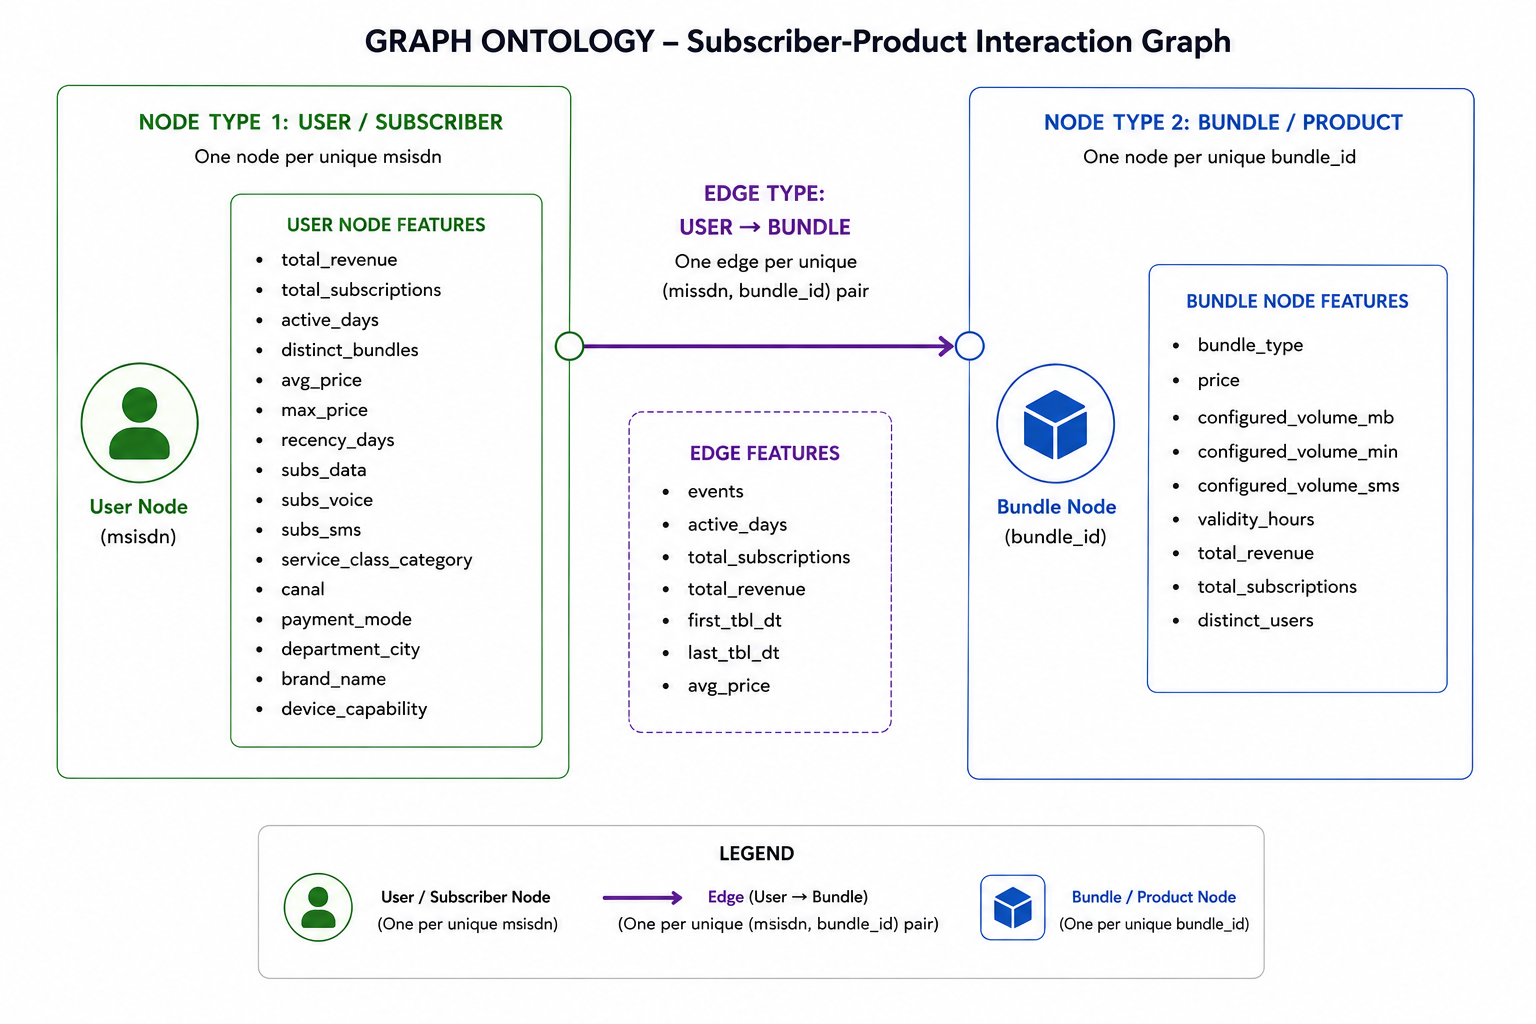

In [2]:
def seed():
    SEED = 42
    seed_everything(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
seed()

In [3]:
WORK_DIR = Path("graph_build_output")
WORK_DIR.mkdir(exist_ok=True)

DB_PATH = WORK_DIR / "graph_build.duckdb"

PARQUET_PATTERNS = [
    "../../datasets/graphsage_data/*.parquet"
]

parquet_files = []
for pattern in PARQUET_PATTERNS:
    parquet_files.extend(glob.glob(pattern))

parquet_files = sorted(set(parquet_files))

print("Number of parquet files found:", len(parquet_files))
print("Example files:", parquet_files[:5])

assert len(parquet_files) > 0, "No parquet files found. Fix PARQUET_PATTERNS."

Number of parquet files found: 16
Example files: ['../../datasets/graphsage_data\\part-00000-10f97a74-36cd-41ae-a55d-0130257e1d4f-c000.snappy.parquet', '../../datasets/graphsage_data\\part-00000-163334d8-886b-4b39-aa3d-701d7ec83c34-c000.snappy.parquet', '../../datasets/graphsage_data\\part-00000-1b4ae870-6984-4c2d-b3b1-aff98344d647-c000.snappy.parquet', '../../datasets/graphsage_data\\part-00000-43bd8cf6-8412-4a0f-9ab8-3f04a5972cb7-c000.snappy.parquet', '../../datasets/graphsage_data\\part-00000-6fd99a9a-2102-49c2-8093-4e94a44f2023-c000.snappy.parquet']


In [4]:
# Connect DuckDB
con = duckdb.connect(str(DB_PATH))

con.execute("PRAGMA threads=4")
con.execute(f"PRAGMA temp_directory='{str(WORK_DIR / 'duckdb_tmp')}'")

raw_rel = con.read_parquet(parquet_files, union_by_name=True)
raw_rel.create_view("raw_in")

┌──────────┬──────────────┬──────────────────┬────────────────────────────────────────────────────┬──────────────┬────────┬───────────────┬───────────┬────────────────────────┬─────────┬──────────────┬─────────────────┬─────────────────────────┬───────────────────┬──────────────────────┬───────────────────────┬───────────────────────┬──────────┬────────────────┐
│  tbl_dt  │    msisdn    │    bundle_id     │                    bundle_name                     │ bundle_type  │ price  │ subscriptions │ total_rev │ service_class_category │  canal  │ payment_mode │ department_city │       brand_name        │ device_capability │ configured_volume_mb │ configured_volume_min │ configured_volume_sms │ validity │ validity_hours │
│  int32   │    int64     │     varchar      │                      varchar                       │   varchar    │ double │     int32     │  double   │        varchar         │ varchar │   varchar    │     varchar     │         varchar         │      varchar      │     

In [5]:
# Normalize raw schema
con.execute("""
CREATE OR REPLACE VIEW raw AS
SELECT
    CAST(tbl_dt AS INTEGER) AS tbl_dt,
    CAST(msisdn AS VARCHAR) AS msisdn,
    CAST(bundle_id AS VARCHAR) AS bundle_id,

    CAST(bundle_name AS VARCHAR) AS bundle_name,
    CAST(bundle_type AS VARCHAR) AS bundle_type,

    CAST(price AS DOUBLE) AS price,
    CAST(subscriptions AS DOUBLE) AS subscriptions,
    CAST(total_rev AS DOUBLE) AS total_rev,

    CAST(service_class_category AS VARCHAR) AS service_class_category,
    CAST(canal AS VARCHAR) AS canal,
    CAST(payment_mode AS VARCHAR) AS payment_mode,
    CAST(department_city AS VARCHAR) AS department_city,
    CAST(brand_name AS VARCHAR) AS brand_name,
    CAST(device_capability AS VARCHAR) AS device_capability,

    CAST(configured_volume_mb AS DOUBLE) AS configured_volume_mb,
    CAST(configured_volume_min AS DOUBLE) AS configured_volume_min,
    CAST(configured_volume_sms AS DOUBLE) AS configured_volume_sms,
    CAST(validity_hours AS DOUBLE) AS validity_hours

FROM raw_in
WHERE msisdn IS NOT NULL
  AND bundle_id IS NOT NULL
  AND tbl_dt IS NOT NULL
""")

In [6]:
# Check date range
date_range = con.execute("""
SELECT
    MIN(tbl_dt) AS min_tbl_dt,
    MAX(tbl_dt) AS max_tbl_dt,
    COUNT(DISTINCT tbl_dt) AS num_days
FROM raw
""").df()

date_range

,min_tbl_dt,max_tbl_dt,num_days
0,20250801,20251031,92


In [7]:
#  Define time split
# Split:
# Train: 20250801 - 20251010
# Val:   20251011 - 20251020
# Test:  20251021 - 20251031

TRAIN_END_DT = 20251010
VAL_END_DT = 20251020

print("Train: tbl_dt <=", TRAIN_END_DT)
print("Val:  ", TRAIN_END_DT, "< tbl_dt <=", VAL_END_DT)
print("Test: tbl_dt >", VAL_END_DT)

Train: tbl_dt <= 20251010
Val:   20251010 < tbl_dt <= 20251020
Test: tbl_dt > 20251020


In [8]:
# Raw split statistics
split_counts = con.execute(f"""
WITH split_raw AS (
    SELECT
        CASE
            WHEN tbl_dt <= {TRAIN_END_DT} THEN 'train'
            WHEN tbl_dt <= {VAL_END_DT} THEN 'val'
            ELSE 'test'
        END AS split,
        msisdn,
        bundle_id
    FROM raw
),
raw_counts AS (
    SELECT
        split,
        COUNT(*) AS raw_rows,
        COUNT(DISTINCT msisdn) AS users,
        COUNT(DISTINCT bundle_id) AS bundles
    FROM split_raw
    GROUP BY split
),
edge_counts AS (
    SELECT
        split,
        COUNT(*) AS unique_user_bundle_edges
    FROM (
        SELECT
            split,
            msisdn,
            bundle_id
        FROM split_raw
        GROUP BY split, msisdn, bundle_id
    ) x
    GROUP BY split
)
SELECT
    r.split,
    r.raw_rows,
    r.users,
    r.bundles,
    e.unique_user_bundle_edges
FROM raw_counts r
JOIN edge_counts e
    ON r.split = e.split
ORDER BY
    CASE r.split
        WHEN 'train' THEN 1
        WHEN 'val' THEN 2
        ELSE 3
    END
""").df()

split_counts

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,split,raw_rows,users,bundles,unique_user_bundle_edges
0,train,57032894,2788699,786,14099002
1,val,9318998,1793305,651,4933093
2,test,10020654,1819044,657,5182939


In [9]:
# Basic graph size statistics
stats = con.execute("""
SELECT
    COUNT(*) AS raw_rows,
    COUNT(DISTINCT msisdn) AS num_user_nodes,
    COUNT(DISTINCT bundle_id) AS num_bundle_nodes,
    COUNT(DISTINCT msisdn || '|' || bundle_id) AS num_unique_user_bundle_edges,
    MIN(tbl_dt) AS min_tbl_dt,
    MAX(tbl_dt) AS max_tbl_dt
FROM raw
""").df()

stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,raw_rows,num_user_nodes,num_bundle_nodes,num_unique_user_bundle_edges,min_tbl_dt,max_tbl_dt
0,76372546,2997025,815,16744710,20250801,20251031


In [10]:
# Check whether each bundle really has one price
bundle_price_check = con.execute("""
WITH price_counts AS (
    SELECT
        bundle_id,
        COUNT(DISTINCT price) AS distinct_prices
    FROM raw
    GROUP BY bundle_id
)
SELECT
    COUNT(*) AS total_bundles,
    SUM(CASE WHEN distinct_prices = 1 THEN 1 ELSE 0 END) AS bundles_with_one_price,
    SUM(CASE WHEN distinct_prices > 1 THEN 1 ELSE 0 END) AS bundles_with_multiple_prices,
    MAX(distinct_prices) AS max_prices_per_bundle
FROM price_counts
""").df()

bundle_price_check

,total_bundles,bundles_with_one_price,bundles_with_multiple_prices,max_prices_per_bundle
0,815,815.0,0.0,1


In [7]:
# Bundle type graph anatomy
bundle_type_stats = con.execute("""
SELECT
    bundle_type,
    COUNT(*) AS raw_rows,
    COUNT(DISTINCT bundle_id) AS unique_bundles,
    COUNT(DISTINCT msisdn) AS unique_users,
    COUNT(DISTINCT msisdn || '|' || bundle_id) AS unique_edges,
    SUM(COALESCE(total_rev, 0)) AS total_revenue
FROM raw
GROUP BY bundle_type
ORDER BY total_revenue DESC
""").df()

bundle_type_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundle_type,raw_rows,unique_bundles,unique_users,unique_edges,total_revenue
0,BUNDLE_VOICE,37932188,289,2451796,6948254,1.042538e+10
1,BUNDLE_DATA,16151593,341,1493245,4706591,8.108538e+09
2,BUNDLE_SMS,22071526,23,1585646,4997041,1.320692e+09
3,INT_BUNDLE_VOICE,101199,147,35119,38552,8.011347e+07
4,OFFNET_BUNDLE_VOICE,114591,1,53437,53437,1.207120e+07
5,FLEXI_BUNDLE,1449,14,785,835,3.560220e+05


In [8]:
#  User degree distribution
user_degree_stats = con.execute("""
WITH user_degree AS (
    SELECT
        msisdn,
        COUNT(DISTINCT bundle_id) AS degree
    FROM raw
    GROUP BY msisdn
)
SELECT
    COUNT(*) AS users,
    AVG(degree) AS avg_degree,
    MIN(degree) AS min_degree,
    MAX(degree) AS max_degree,
    approx_quantile(degree, 0.50) AS p50_degree,
    approx_quantile(degree, 0.75) AS p75_degree,
    approx_quantile(degree, 0.90) AS p90_degree,
    approx_quantile(degree, 0.95) AS p95_degree,
    approx_quantile(degree, 0.99) AS p99_degree
FROM user_degree
""").df()

user_degree_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,users,avg_degree,min_degree,max_degree,p50_degree,p75_degree,p90_degree,p95_degree,p99_degree
0,2997025,5.587111,1,46,4,8,12,15,20


In [9]:
# Bundle degree distribution
bundle_degree_stats = con.execute("""
WITH bundle_degree AS (
    SELECT
        bundle_id,
        COUNT(DISTINCT msisdn) AS degree
    FROM raw
    GROUP BY bundle_id
)
SELECT
    COUNT(*) AS bundles,
    AVG(degree) AS avg_degree,
    MIN(degree) AS min_degree,
    MAX(degree) AS max_degree,
    approx_quantile(degree, 0.50) AS p50_degree,
    approx_quantile(degree, 0.75) AS p75_degree,
    approx_quantile(degree, 0.90) AS p90_degree,
    approx_quantile(degree, 0.95) AS p95_degree,
    approx_quantile(degree, 0.99) AS p99_degree
FROM bundle_degree
""").df()

bundle_degree_stats

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,bundles,avg_degree,min_degree,max_degree,p50_degree,p75_degree,p90_degree,p95_degree,p99_degree
0,815,20545.656442,1,1192839,91,2534,25208,81121,493078


In [11]:
# Build train-only user nodes
# Important: Nodes and features are built from training history only.
# This avoids leakage from validation/test future behavior.

con.execute(f"""
CREATE OR REPLACE TABLE user_nodes_train AS
WITH user_agg AS (
    SELECT
        msisdn,

        COUNT(*) AS raw_events,
        COUNT(DISTINCT tbl_dt) AS active_days,
        COUNT(DISTINCT bundle_id) AS distinct_bundles,

        SUM(COALESCE(subscriptions, 0)) AS total_subscriptions,
        SUM(COALESCE(total_rev, 0)) AS total_revenue,

        AVG(COALESCE(price, 0)) AS avg_price,
        MAX(COALESCE(price, 0)) AS max_price,

        SUM(
            CASE
                WHEN bundle_type = 'BUNDLE_DATA'
                THEN COALESCE(subscriptions, 0)
                ELSE 0
            END
        ) AS subs_data,

        SUM(
            CASE
                WHEN bundle_type = 'BUNDLE_VOICE'
                THEN COALESCE(subscriptions, 0)
                ELSE 0
            END
        ) AS subs_voice,

        SUM(
            CASE
                WHEN bundle_type = 'BUNDLE_SMS'
                THEN COALESCE(subscriptions, 0)
                ELSE 0
            END
        ) AS subs_sms,

        MAX(tbl_dt) AS last_seen_tbl_dt,

        COALESCE(ARG_MAX(service_class_category, tbl_dt), 'UNK') AS service_class_category,
        COALESCE(ARG_MAX(canal, tbl_dt), 'UNK') AS canal,
        COALESCE(ARG_MAX(payment_mode, tbl_dt), 'UNK') AS payment_mode,
        COALESCE(ARG_MAX(department_city, tbl_dt), 'UNK') AS department_city,
        COALESCE(ARG_MAX(brand_name, tbl_dt), 'UNK') AS brand_name,
        COALESCE(ARG_MAX(device_capability, tbl_dt), 'UNK') AS device_capability

    FROM raw
    WHERE tbl_dt <= {TRAIN_END_DT}
    GROUP BY msisdn
)
SELECT
    ROW_NUMBER() OVER (ORDER BY msisdn) - 1 AS user_idx,
    *
FROM user_agg
""")

print("Built user_nodes_train.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built user_nodes_train.


In [12]:
# Cell 9: Build train-only bundle nodes
# Bundle ontology: Keep only one price because each bundle has one price.
# ARG_MAX(price, tbl_dt) takes the latest observed price.

con.execute(f"""
CREATE OR REPLACE TABLE bundle_nodes_train AS
WITH bundle_agg AS (
    SELECT
        bundle_id,

        COALESCE(ARG_MAX(bundle_name, tbl_dt), 'UNK') AS bundle_name,
        COALESCE(ARG_MAX(bundle_type, tbl_dt), 'UNK') AS bundle_type,

        COALESCE(ARG_MAX(price, tbl_dt), 0) AS price,

        AVG(COALESCE(configured_volume_mb, 0)) AS configured_volume_mb,
        AVG(COALESCE(configured_volume_min, 0)) AS configured_volume_min,
        AVG(COALESCE(configured_volume_sms, 0)) AS configured_volume_sms,
        AVG(COALESCE(validity_hours, 0)) AS validity_hours,

        COUNT(*) AS raw_events,
        COUNT(DISTINCT msisdn) AS distinct_users,

        SUM(COALESCE(subscriptions, 0)) AS total_subscriptions,
        SUM(COALESCE(total_rev, 0)) AS total_revenue,

        MIN(tbl_dt) AS first_seen_tbl_dt,
        MAX(tbl_dt) AS last_seen_tbl_dt

    FROM raw
    WHERE tbl_dt <= {TRAIN_END_DT}
    GROUP BY bundle_id
)
SELECT
    ROW_NUMBER() OVER (ORDER BY bundle_id) - 1 AS bundle_idx,
    *
FROM bundle_agg
""")

print("Built bundle_nodes_train.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built bundle_nodes_train.


In [13]:
# Build train edges
# One row = one graph edge.
# Edge = user subscribed to bundle during train period.

con.execute(f"""
CREATE OR REPLACE TABLE train_edges AS
WITH edge_agg AS (
    SELECT
        msisdn,
        bundle_id,

        COUNT(*) AS raw_events,
        COUNT(DISTINCT tbl_dt) AS active_days,

        SUM(COALESCE(subscriptions, 0)) AS total_subscriptions,
        SUM(COALESCE(total_rev, 0)) AS total_revenue,

        COALESCE(ARG_MAX(price, tbl_dt), 0) AS price,

        MIN(tbl_dt) AS first_tbl_dt,
        MAX(tbl_dt) AS last_tbl_dt

    FROM raw
    WHERE tbl_dt <= {TRAIN_END_DT}
    GROUP BY msisdn, bundle_id
)
SELECT
    u.user_idx,
    b.bundle_idx,

    e.msisdn,
    e.bundle_id,

    e.raw_events,
    e.active_days,
    e.total_subscriptions,
    e.total_revenue,
    e.price,
    e.first_tbl_dt,
    e.last_tbl_dt

FROM edge_agg e
JOIN user_nodes_train u
    ON e.msisdn = u.msisdn
JOIN bundle_nodes_train b
    ON e.bundle_id = b.bundle_id
""")

print("Built train_edges.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built train_edges.


In [14]:
# Build validation edges
# Validation edges are future purchases after train.
# We keep only users and bundles known in training.

con.execute(f"""
CREATE OR REPLACE TABLE val_edges AS
WITH edge_agg AS (
    SELECT
        msisdn,
        bundle_id,

        COUNT(*) AS raw_events,
        COUNT(DISTINCT tbl_dt) AS active_days,

        SUM(COALESCE(subscriptions, 0)) AS total_subscriptions,
        SUM(COALESCE(total_rev, 0)) AS total_revenue,

        COALESCE(ARG_MAX(price, tbl_dt), 0) AS price,

        MIN(tbl_dt) AS first_tbl_dt,
        MAX(tbl_dt) AS last_tbl_dt

    FROM raw
    WHERE tbl_dt > {TRAIN_END_DT}
      AND tbl_dt <= {VAL_END_DT}
    GROUP BY msisdn, bundle_id
)
SELECT
    u.user_idx,
    b.bundle_idx,

    e.msisdn,
    e.bundle_id,

    e.raw_events,
    e.active_days,
    e.total_subscriptions,
    e.total_revenue,
    e.price,
    e.first_tbl_dt,
    e.last_tbl_dt

FROM edge_agg e
JOIN user_nodes_train u
    ON e.msisdn = u.msisdn
JOIN bundle_nodes_train b
    ON e.bundle_id = b.bundle_id
""")

print("Built val_edges.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built val_edges.


In [15]:
#  Build test edges
# Test edges are the latest future purchases.
# We keep only users and bundles known in training.

con.execute(f"""
CREATE OR REPLACE TABLE test_edges AS
WITH edge_agg AS (
    SELECT
        msisdn,
        bundle_id,

        COUNT(*) AS raw_events,
        COUNT(DISTINCT tbl_dt) AS active_days,

        SUM(COALESCE(subscriptions, 0)) AS total_subscriptions,
        SUM(COALESCE(total_rev, 0)) AS total_revenue,

        COALESCE(ARG_MAX(price, tbl_dt), 0) AS price,

        MIN(tbl_dt) AS first_tbl_dt,
        MAX(tbl_dt) AS last_tbl_dt

    FROM raw
    WHERE tbl_dt > {VAL_END_DT}
    GROUP BY msisdn, bundle_id
)
SELECT
    u.user_idx,
    b.bundle_idx,

    e.msisdn,
    e.bundle_id,

    e.raw_events,
    e.active_days,
    e.total_subscriptions,
    e.total_revenue,
    e.price,
    e.first_tbl_dt,
    e.last_tbl_dt

FROM edge_agg e
JOIN user_nodes_train u
    ON e.msisdn = u.msisdn
JOIN bundle_nodes_train b
    ON e.bundle_id = b.bundle_id
""")

print("Built test_edges.")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Built test_edges.


In [16]:
# Report graph sizes
graph_size_report = con.execute("""
SELECT
    (SELECT COUNT(*) FROM user_nodes_train) AS train_user_nodes,
    (SELECT COUNT(*) FROM bundle_nodes_train) AS train_bundle_nodes,
    (SELECT COUNT(*) FROM train_edges) AS train_edges,
    (SELECT COUNT(*) FROM val_edges) AS val_edges,
    (SELECT COUNT(*) FROM test_edges) AS test_edges
""").df()

graph_size_report

,train_user_nodes,train_bundle_nodes,train_edges,val_edges,test_edges
0,2788699,786,14099002,4767544,4892304


In [17]:
# Check filtered-out cold-start users/bundles
# These are validation/test interactions removed because the user or bundle
# was not seen during training.
# This is not bad. It simply tells you how much cold-start exists.

cold_start_report = con.execute(f"""
WITH future_edges AS (
    SELECT
        CASE
            WHEN tbl_dt <= {VAL_END_DT} THEN 'val'
            ELSE 'test'
        END AS split,
        msisdn,
        bundle_id
    FROM raw
    WHERE tbl_dt > {TRAIN_END_DT}
    GROUP BY split, msisdn, bundle_id
),
marked AS (
    SELECT
        f.split,
        f.msisdn,
        f.bundle_id,
        CASE WHEN u.msisdn IS NULL THEN 1 ELSE 0 END AS is_new_user,
        CASE WHEN b.bundle_id IS NULL THEN 1 ELSE 0 END AS is_new_bundle
    FROM future_edges f
    LEFT JOIN user_nodes_train u
        ON f.msisdn = u.msisdn
    LEFT JOIN bundle_nodes_train b
        ON f.bundle_id = b.bundle_id
)
SELECT
    split,
    COUNT(*) AS future_edges_total,
    SUM(is_new_user) AS edges_with_new_user,
    SUM(is_new_bundle) AS edges_with_new_bundle,
    SUM(
        CASE
            WHEN is_new_user = 0 AND is_new_bundle = 0
            THEN 1
            ELSE 0
        END
    ) AS usable_edges_for_transductive_eval
FROM marked
GROUP BY split
ORDER BY
    CASE split
        WHEN 'val' THEN 1
        ELSE 2
    END
""").df()

cold_start_report

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,split,future_edges_total,edges_with_new_user,edges_with_new_bundle,usable_edges_for_transductive_eval
0,val,4933093,149163.0,16943.0,4767544.0
1,test,5182939,217326.0,77873.0,4892304.0


In [29]:
# Sparsity report for train graph

train_sparsity_report = con.execute("""
WITH s AS (
    SELECT
        (SELECT COUNT(*) FROM user_nodes_train) AS num_users,
        (SELECT COUNT(*) FROM bundle_nodes_train) AS num_bundles,
        (SELECT COUNT(*) FROM train_edges) AS num_edges
)
SELECT
    num_users,
    num_bundles,
    num_edges,
    num_users * num_bundles AS possible_edges,
    num_edges * 1.0 / NULLIF(num_users * num_bundles, 0) AS graph_density
FROM s
""").df()

train_sparsity_report

,num_users,num_bundles,num_edges,possible_edges,graph_density
0,2788699,786,14099002,2191917414,0.006432


In [22]:
# Inspect samples
user_nodes_sample = con.execute("""
SELECT *
FROM user_nodes_train
LIMIT 200
""").df()

bundle_nodes_sample = con.execute("""
SELECT *
FROM bundle_nodes_train
LIMIT 200
""").df()

train_edges_sample = con.execute("""
SELECT *
FROM train_edges
LIMIT 1000
""").df()

val_edges_sample = con.execute("""
SELECT *
FROM val_edges
LIMIT 5
""").df()

test_edges_sample = con.execute("""
SELECT *
FROM test_edges
LIMIT 5
""").df()

display(user_nodes_sample.head())
display(bundle_nodes_sample.head())
display(train_edges_sample.head())
display(val_edges_sample.head())
display(test_edges_sample.head())

,user_idx,msisdn,raw_events,active_days,distinct_bundles,total_subscriptions,total_revenue,avg_price,max_price,subs_data,subs_voice,subs_sms,last_seen_tbl_dt,service_class_category,canal,payment_mode,department_city,brand_name,device_capability
0,0,242061000000,6,6,5,6.0,4310.0,718.333333,1200.0,6.0,0.0,0.0,20250922,PREPAID,LEAP,AIRTIME,BRAZZAVILLE,Samsung,5G
1,1,242061000303,2,2,2,2.0,825.0,412.500000,525.0,0.0,2.0,0.0,20251007,PREPAID,ECW,MOMO,UnknownCity,Apple,4G
2,2,242061000404,28,22,16,28.0,11299.0,403.535714,1400.0,12.0,14.0,2.0,20250928,PREPAID,ECW,MOMO,UnknownCity,Tecno Telecom,4G
3,3,242061000505,15,11,8,15.0,4693.0,312.866667,650.0,2.0,11.0,2.0,20251002,PREPAID,ECW,MOMO,BRAZZAVILLE,Oraimo Technology Limited,3G
4,4,242061001010,20,19,9,20.0,7495.0,404.650000,1210.0,3.0,9.0,8.0,20251005,PREPAID,LENDING,LENDING,BRAZZAVILLE,Oppo,5G


,bundle_idx,bundle_id,bundle_name,bundle_type,price,configured_volume_mb,configured_volume_min,configured_volume_sms,validity_hours,raw_events,distinct_users,total_subscriptions,total_revenue,first_seen_tbl_dt,last_seen_tbl_dt
0,0,1000,COPEPCO Association@2000,BUNDLE_VOICE,2000.0,0.0,0.0,0.0,720.0,9,5,9.0,18000.0,20250807,20251010
1,1,1005,SCC BZV Association@2000,BUNDLE_VOICE,2000.0,0.0,0.0,0.0,720.0,1,1,1.0,2000.0,20250812,20250812
2,2,35021,Forfait 1 jour 20MB 256Kbps@106F,BUNDLE_DATA,106.0,0.0,0.0,0.0,24.0,9,8,9.0,954.0,20250804,20251009
3,3,35025,Forfait 1 jour 61MB@255F,BUNDLE_DATA,255.0,0.0,0.0,0.0,24.0,1340,614,1477.0,376635.0,20250801,20251010
4,4,35030,Pack Standard Internet,BUNDLE_DATA,5000.0,2048.0,0.0,0.0,720.0,21,21,21.0,105000.0,20250804,20251007


,user_idx,bundle_idx,msisdn,bundle_id,raw_events,active_days,total_subscriptions,total_revenue,price,first_tbl_dt,last_tbl_dt
0,1821202,687,242067711337,SMSPK50,5,5,5.0,330.0,66.0,20250818,20250912
1,2640952,614,242069653205,FVX1D120FV3,1,1,1.0,120.0,120.0,20250824,20250824
2,414025,610,242064423389,FVX1D100FV4,20,20,21.0,2100.0,100.0,20250806,20251010
3,679828,610,242065047115,FVX1D100FV4,5,5,5.0,500.0,100.0,20250808,20250906
4,1086768,602,242066051343,COMVIVASMSPK100BoGo,5,5,5.0,610.0,122.0,20250815,20251010


,user_idx,bundle_idx,msisdn,bundle_id,raw_events,active_days,total_subscriptions,total_revenue,price,first_tbl_dt,last_tbl_dt
0,1812499,160,242067683921,36778,8,6,8.0,1760.0,220.0,20251011,20251020
1,2161450,602,242068567559,COMVIVASMSPK100BoGo,3,3,3.0,366.0,122.0,20251012,20251020
2,1726522,685,242067444986,SMSPK15,2,2,2.0,52.0,26.0,20251017,20251019
3,963294,116,242065750351,36600,3,3,3.0,600.0,200.0,20251013,20251020
4,1198541,233,242066267020,36989,2,2,2.0,1000.0,500.0,20251017,20251018


,user_idx,bundle_idx,msisdn,bundle_id,raw_events,active_days,total_subscriptions,total_revenue,price,first_tbl_dt,last_tbl_dt
0,1820669,617,242067709827,FVX1D150FV4,1,1,1.0,150.0,150.0,20251028,20251028
1,1599218,614,242067063451,FVX1D120FV3,2,1,2.0,240.0,120.0,20251031,20251031
2,1792290,622,242067629036,FVX1D200FV3,2,2,2.0,400.0,200.0,20251022,20251030
3,1573298,622,242066994840,FVX1D200FV3,1,1,1.0,200.0,200.0,20251027,20251027
4,2183090,610,242068618448,FVX1D100FV4,3,3,4.0,400.0,100.0,20251021,20251026


In [57]:
# Get a sample of edges first
train_edges_sample = con.execute("""
    SELECT *
    FROM train_edges
    LIMIT 1000
""").df()

# Step 2: Get ONLY users that appear in those edges
user_ids = tuple(train_edges_sample["msisdn"].unique().tolist())
user_nodes_sample = con.execute(f"""
    SELECT *
    FROM user_nodes_train
    WHERE msisdn IN {user_ids}
""").df()

# Step 3: Get ONLY bundles that appear in those edges
bundle_ids = tuple(train_edges_sample["bundle_id"].unique().tolist())
bundle_nodes_sample = con.execute(f"""
    SELECT *
    FROM bundle_nodes_train
    WHERE bundle_id IN {bundle_ids}
""").df()

print(f"Users:   {len(user_nodes_sample)}")
print(f"Bundles: {len(bundle_nodes_sample)}")
print(f"Edges:   {len(train_edges_sample)}")

Users:   999
Bundles: 99
Edges:   1000


In [58]:
import plotly.graph_objects as go
import networkx as nx
import numpy as np

G = nx.DiGraph()

for _, row in user_nodes_sample.iterrows():
    G.add_node(row["msisdn"], type="user", **row.to_dict())

for _, row in bundle_nodes_sample.iterrows():
    G.add_node(row["bundle_id"], type="bundle", **row.to_dict())

for _, row in train_edges_sample.iterrows():
    G.add_edge(row["msisdn"], row["bundle_id"], **row.to_dict())

pos = nx.spring_layout(
    G,
    seed=42,
    k=1.2,
    iterations=100
)

# Edge traces
edge_x, edge_y = [], []
edge_hover_x, edge_hover_y, edge_hover_text = [], [], []

for u, v, data in G.edges(data=True):
    x0, y0 = pos[u]
    x1, y1 = pos[v]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]
    edge_hover_x.append((x0 + x1) / 2)
    edge_hover_y.append((y0 + y1) / 2)
    edge_hover_text.append(
        f"<b>Subscription</b><br>"
        f"User: {u}<br>"
        f"Bundle: {v}<br>"
        f"Subscriptions: {data.get('total_subscriptions', 'N/A')}<br>"
        f"Revenue: {data.get('total_revenue', 'N/A')}<br>"
        f"Price: {data.get('price', 'N/A')}"
    )

edge_trace = go.Scatter(
    x=edge_x,
    y=edge_y,
    mode="lines",
    line=dict(width=1.2, color="rgba(100,100,100,0.18)"),
    hoverinfo="none",
    showlegend=False
)

edge_hover_trace = go.Scatter(
    x=edge_hover_x,
    y=edge_hover_y,
    mode="markers",
    marker=dict(size=10, color="rgba(0,0,0,0)"),
    hovertemplate="%{text}<extra></extra>",
    text=edge_hover_text,
    showlegend=False
)

# Node styling
user_nodes_list = [n for n, d in G.nodes(data=True) if d.get("type") == "user"]
bundle_nodes_list = [n for n, d in G.nodes(data=True) if d.get("type") == "bundle"]

def make_node_trace(nodes, color, symbol, name):
    x, y, hover, sizes = [], [], [], []
    for n in nodes:
        d = G.nodes[n]
        x.append(pos[n][0])
        y.append(pos[n][1])

        degree = G.degree(n)
        sizes.append(min(18 + degree * 2.5, 34))

        if d.get("type") == "user":
            hover.append(
                f"<b>User</b><br>"
                f"MSISDN: {n}<br>"
                f"Active days: {d.get('active_days', 'N/A')}<br>"
                f"Revenue: {d.get('total_revenue', 'N/A')}<br>"
                f"Bundles: {d.get('distinct_bundles', 'N/A')}<br>"
                f"Device: {d.get('device_capability', 'N/A')}<br>"
                f"Brand: {d.get('brand_name', 'N/A')}"
            )
        else:
            hover.append(
                f"<b>Bundle</b><br>"
                f"ID: {n}<br>"
                f"Name: {d.get('bundle_name', 'N/A')}<br>"
                f"Type: {d.get('bundle_type', 'N/A')}<br>"
                f"Price: {d.get('price', 'N/A')}<br>"
                f"Revenue: {d.get('total_revenue', 'N/A')}<br>"
                f"Users: {d.get('distinct_users', 'N/A')}"
            )

    return go.Scatter(
        x=x,
        y=y,
        mode="markers",
        name=name,
        hovertemplate="%{text}<extra></extra>",
        text=hover,
        marker=dict(
            size=sizes,
            color=color,
            symbol=symbol,
            line=dict(width=1.8, color="white"),
            opacity=0.95
        )
    )

user_trace = make_node_trace(user_nodes_list, "#4C78A8", "circle", "Users")
bundle_trace = make_node_trace(bundle_nodes_list, "#F58518", "diamond", "Bundles")

fig = go.Figure(data=[edge_trace, edge_hover_trace, user_trace, bundle_trace])

fig.update_layout(
    template="simple_white",
    title=dict(
        text="<b>User–Bundle Bipartite Graph</b><br><span style='font-size:12px;color:#7a7a7a'>Interactive network view of users and bundles</span>",
        x=0.5,
        xanchor="center"
    ),
    font=dict(family="Inter, Arial, sans-serif", size=13, color="#2b2b2b"),
    paper_bgcolor="white",
    plot_bgcolor="white",
    margin=dict(l=20, r=20, t=80, b=20),
    height=760,
    hovermode="closest",
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.update_xaxes(visible=False)
fig.update_yaxes(visible=False)

fig.show()

In [19]:
# Save graph tables to parquet
con.execute(f"""
COPY user_nodes_train
TO '{str(WORK_DIR / "user_nodes_train.parquet")}'
(FORMAT PARQUET)
""")

con.execute(f"""
COPY bundle_nodes_train
TO '{str(WORK_DIR / "bundle_nodes_train.parquet")}'
(FORMAT PARQUET)
""")

con.execute(f"""
COPY train_edges
TO '{str(WORK_DIR / "train_edges.parquet")}'
(FORMAT PARQUET)
""")

con.execute(f"""
COPY val_edges
TO '{str(WORK_DIR / "val_edges.parquet")}'
(FORMAT PARQUET)
""")

con.execute(f"""
COPY test_edges
TO '{str(WORK_DIR / "test_edges.parquet")}'
(FORMAT PARQUET)
""")

print("Saved graph tables to:", WORK_DIR)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Saved graph tables to: graph_build_output


## Train GraphSAGE 

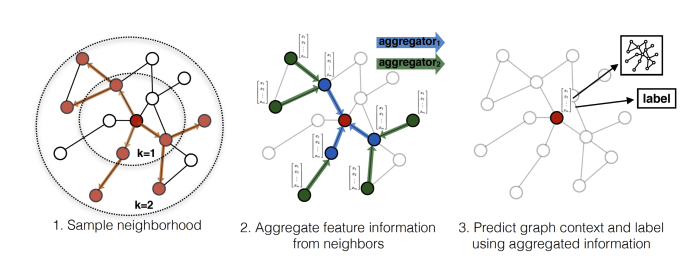

The working process of GraphSage is mainly divided into two steps, first performing <b>neighborhood sampling</b>  of an input graph and the second one is <b>learning aggregation functions</b> at each search depth. the importance of learning aggregator functions is basically had helped GraphSage algorithm to achieve its property of <b>inductiveness</b>.

* search depth (K) which informs the algorithm upto what depth it should gather the information from the neighborhood of a target node. Here, K is a hyperparameter and it also depicts the number of layers used in the model.

* neighborhood sampling: for every node randomly sample a fixed number of neighbors, aggregate their features, and repeat layer-by-layer (K Layers).




In [2]:
WORK_DIR = Path("graph_build_output")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

print("Device:", DEVICE)

Device: cuda


In [3]:
def seed(SEED: int):
    seed_everything(SEED)
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)

SEED = 42
seed(SEED)

In [4]:
EDGE_TYPE = ("user", "subscribed_to", "bundle")
REV_EDGE_TYPE = ("bundle", "rev_subscribed_by", "user")

HIDDEN_DIM = 64
CAT_EMB_DIM = 16
NUM_LAYERS = 2 # represents K 
DROPOUT = 0.25

TRAIN_BATCH_SIZE = 2048
EVAL_BATCH_SIZE = 4096

# interactions that did NOT happen.
NEG_SAMPLING_RATIO_TRAIN = 2.0
NEG_SAMPLING_RATIO_EVAL = 20.0

# Neighborhood Sampling
# First layer Sample 15 neighbors for target node,
# Second layer Sample 10 neighbors for each of those 15 nodes.
NUM_NEIGHBORS = {
    EDGE_TYPE: [15, 10],
    REV_EDGE_TYPE: [15, 10],
}

EPOCHS = 5
LR = 2e-3
WEIGHT_DECAY = 1e-4

MAX_EVAL_EDGES = 200_000
TOPK_USER_LIMIT = 3000

In [5]:
user_nodes_df = pd.read_parquet(WORK_DIR / "user_nodes_train.parquet")
bundle_nodes_df = pd.read_parquet(WORK_DIR / "bundle_nodes_train.parquet")

train_edges_df = pd.read_parquet(
    WORK_DIR / "train_edges.parquet",
    columns=["user_idx", "bundle_idx"],
)

val_edges_df = pd.read_parquet(
    WORK_DIR / "val_edges.parquet",
    columns=["user_idx", "bundle_idx"],
)

test_edges_df = pd.read_parquet(
    WORK_DIR / "test_edges.parquet",
    columns=["user_idx", "bundle_idx"],
)

print("Users:", len(user_nodes_df))
print("Bundles:", len(bundle_nodes_df))
print("Train edges:", len(train_edges_df))
print("Val edges:", len(val_edges_df))
print("Test edges:", len(test_edges_df))

Users: 2788699
Bundles: 786
Train edges: 14099002
Val edges: 4767544
Test edges: 4892304


In [6]:
USER_NUM_COLS = [
    "raw_events",
    "active_days",
    "distinct_bundles",
    "total_subscriptions",
    "total_revenue",
    "avg_price",
    "max_price",
    "subs_data",
    "subs_voice",
    "subs_sms",
]

USER_CAT_COLS = [
    "service_class_category",
    "canal",
    "payment_mode",
    "department_city",
    "brand_name",
    "device_capability",
]

BUNDLE_NUM_COLS = [
    "price",
    "configured_volume_mb",
    "configured_volume_min",
    "configured_volume_sms",
    "validity_hours",
    "raw_events",
    "distinct_users",
    "total_subscriptions",
    "total_revenue",
]

BUNDLE_CAT_COLS = [
    "bundle_type",
]

In [7]:
# Feature encoding 
def fit_numeric(df, cols):
    x = df[cols].replace([np.inf, -np.inf], np.nan).astype("float32")

    mean = x.mean(axis=0).astype("float32")
    std = x.std(axis=0).replace(0, 1).astype("float32")

    x = x.fillna(mean)
    x = ((x - mean) / std).astype("float32")

    return x.to_numpy(), mean.to_dict(), std.to_dict()


def fit_categorical(df, cols):
    cat_arrays = []
    maps = {}
    cardinalities = []

    for col in cols:
        s = df[col].fillna("UNK").astype(str)

        values = pd.Index(s.unique())
        mapping = {v: i for i, v in enumerate(values)}
        unk_idx = len(mapping)

        arr = s.map(mapping).fillna(unk_idx).astype("int64").to_numpy()

        cat_arrays.append(arr)
        maps[col] = mapping
        cardinalities.append(len(mapping) + 1)

    if len(cat_arrays) == 0:
        return np.zeros((len(df), 0), dtype=np.int64), maps, cardinalities

    return np.stack(cat_arrays, axis=1), maps, cardinalities

In [8]:
# Encode user and bundle features
user_x_num, user_num_mean, user_num_std = fit_numeric(user_nodes_df, USER_NUM_COLS)
bundle_x_num, bundle_num_mean, bundle_num_std = fit_numeric(bundle_nodes_df, BUNDLE_NUM_COLS)

user_x_cat, user_cat_maps, user_cat_cardinalities = fit_categorical(user_nodes_df, USER_CAT_COLS)
bundle_x_cat, bundle_cat_maps, bundle_cat_cardinalities = fit_categorical(bundle_nodes_df, BUNDLE_CAT_COLS)

print("user_x_num:", user_x_num.shape)
print("user_x_cat:", user_x_cat.shape)
print("bundle_x_num:", bundle_x_num.shape)
print("bundle_x_cat:", bundle_x_cat.shape)

print("User categorical cardinalities:", dict(zip(USER_CAT_COLS, user_cat_cardinalities)))
print("Bundle categorical cardinalities:", dict(zip(BUNDLE_CAT_COLS, bundle_cat_cardinalities)))

user_x_num: (2788699, 10)
user_x_cat: (2788699, 6)
bundle_x_num: (786, 9)
bundle_x_cat: (786, 1)
User categorical cardinalities: {'service_class_category': 3, 'canal': 5, 'payment_mode': 4, 'department_city': 15, 'brand_name': 1197, 'device_capability': 6}
Bundle categorical cardinalities: {'bundle_type': 7}


In [9]:
user_x_num[1:5], user_x_cat[1:5]

(array([[-0.72343343, -0.85885996, -0.75021875, -0.7044764 , -0.51877254,
          0.14215098, -0.00789142, -0.41679236, -0.53279144, -0.5207591 ],
        [ 0.29595986,  0.48023322,  2.6869135 ,  0.2463248 ,  0.6897682 ,
          0.13208503,  0.7449376 ,  0.700669  ,  0.20764868, -0.34963322],
        [-0.21373679, -0.25626802,  0.7228379 , -0.22907582, -0.07246398,
          0.03027323,  0.09965558, -0.23054881,  0.02253865, -0.34963322],
        [-0.01769961,  0.27936926,  0.9683474 , -0.04622943,  0.25084433,
          0.13333626,  0.5814662 , -0.13742703, -0.10086803,  0.16374448]],
       dtype=float32),
 array([[0, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 2, 1],
        [0, 1, 1, 0, 3, 2],
        [0, 2, 2, 0, 4, 0]]))

In [10]:
bundle_x_num[1:5], bundle_x_cat[1:5]

(array([[-0.17123283, -0.1271111 , -0.3075195 , -0.07792902,  1.3519433 ,
         -0.1626874 , -0.20496136, -0.16226208, -0.21010232],
        [-0.28745928, -0.1271111 , -0.3075195 , -0.07792902, -0.8585291 ,
         -0.16266948, -0.20488137, -0.16224487, -0.21011396],
        [-0.2783158 , -0.1271111 , -0.3075195 , -0.07792902, -0.8585291 ,
         -0.15968522, -0.19795664, -0.15908754, -0.20593256],
        [ 0.01286398, -0.08846467, -0.3075195 , -0.07792902,  1.3519433 ,
         -0.16264257, -0.20473282, -0.16221906, -0.2089559 ]],
       dtype=float32),
 array([[0],
        [1],
        [1],
        [1]]))

In [30]:
# Build ID maps for inference
msisdn_to_user_idx = dict(
    zip(
        user_nodes_df["msisdn"].astype(str),
        user_nodes_df["user_idx"].astype(int),
    )
)

bundle_idx_to_bundle_id = dict(
    zip(
        bundle_nodes_df["bundle_idx"].astype(int),
        bundle_nodes_df["bundle_id"].astype(str),
    )
)

bundle_idx_to_bundle_name = dict(
    zip(
        bundle_nodes_df["bundle_idx"].astype(int),
        bundle_nodes_df["bundle_name"].astype(str),
    )
)

bundle_idx_to_bundle_type = dict(
    zip(
        bundle_nodes_df["bundle_idx"].astype(int),
        bundle_nodes_df["bundle_type"].astype(str),
    )
)

bundle_idx_to_price = dict(
    zip(
        bundle_nodes_df["bundle_idx"].astype(int),
        bundle_nodes_df["price"].astype(float),
    )
)

ALL_BUNDLE_INDICES = bundle_nodes_df["bundle_idx"].astype(int).to_numpy()

In [12]:
import json

metadata = {
    "msisdn_to_user_idx": {
        str(k): int(v)
        for k, v in msisdn_to_user_idx.items()
    },

    "bundle_idx_to_bundle_id": {
        str(k): str(v)
        for k, v in bundle_idx_to_bundle_id.items()
    },

    "bundle_idx_to_bundle_name": {
        str(k): str(v)
        for k, v in bundle_idx_to_bundle_name.items()
    },

    "bundle_idx_to_bundle_type": {
        str(k): str(v)
        for k, v in bundle_idx_to_bundle_type.items()
    },

    "bundle_idx_to_price": {
        str(k): float(v)
        for k, v in bundle_idx_to_price.items()
    },

    "all_bundle_indices": ALL_BUNDLE_INDICES.tolist(),
}

with open("graphsage_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

In [13]:
feature_metadata = {
    "user_num_mean": {
        k: float(v)
        for k, v in user_num_mean.items()
    },

    "user_num_std": {
        k: float(v)
        for k, v in user_num_std.items()
    },

    "bundle_num_mean": {
        k: float(v)
        for k, v in bundle_num_mean.items()
    },

    "bundle_num_std": {
        k: float(v)
        for k, v in bundle_num_std.items()
    },

    "user_cat_maps": {
        col: {
            str(k): int(v)
            for k, v in mapping.items()
        }
        for col, mapping in user_cat_maps.items()
    },

    "bundle_cat_maps": {
        col: {
            str(k): int(v)
            for k, v in mapping.items()
        }
        for col, mapping in bundle_cat_maps.items()
    },

    "user_cat_cardinalities": {
        col: int(card)
        for col, card in zip(USER_CAT_COLS, user_cat_cardinalities)
    },

    "bundle_cat_cardinalities": {
        col: int(card)
        for col, card in zip(BUNDLE_CAT_COLS, bundle_cat_cardinalities)
    },
}

with open("cat_features_metadata.json", "w") as f:
    json.dump(feature_metadata, f, indent=4)

In [11]:
# Build PyTorch Geometric HeteroData graph

train_edge_index = torch.tensor(
    train_edges_df[["user_idx", "bundle_idx"]].to_numpy().T,
    dtype=torch.long,
).contiguous()

val_edge_label_index = torch.tensor(
    val_edges_df[["user_idx", "bundle_idx"]].to_numpy().T,
    dtype=torch.long,
).contiguous()

test_edge_label_index = torch.tensor(
    test_edges_df[["user_idx", "bundle_idx"]].to_numpy().T,
    dtype=torch.long,
).contiguous()

data = HeteroData()

data["user"].x_num = torch.from_numpy(user_x_num)
data["user"].x_cat = torch.from_numpy(user_x_cat)
data["user"].num_nodes = len(user_nodes_df)

data["bundle"].x_num = torch.from_numpy(bundle_x_num)
data["bundle"].x_cat = torch.from_numpy(bundle_x_cat)
data["bundle"].num_nodes = len(bundle_nodes_df)

data[EDGE_TYPE].edge_index = train_edge_index
data[REV_EDGE_TYPE].edge_index = train_edge_index.flip(0).contiguous()

print(data)
print("Train edge_index:", data[EDGE_TYPE].edge_index.shape)
print("Val edge_label_index:", val_edge_label_index.shape)
print("Test edge_label_index:", test_edge_label_index.shape)

del train_edges_df
gc.collect()

HeteroData(
  user={
    x_num=[2788699, 10],
    x_cat=[2788699, 6],
    num_nodes=2788699,
  },
  bundle={
    x_num=[786, 9],
    x_cat=[786, 1],
    num_nodes=786,
  },
  (user, subscribed_to, bundle)={ edge_index=[2, 14099002] },
  (bundle, rev_subscribed_by, user)={ edge_index=[2, 14099002] }
)
Train edge_index: torch.Size([2, 14099002])
Val edge_label_index: torch.Size([2, 4767544])
Test edge_label_index: torch.Size([2, 4892304])


106

In [12]:
data['user']

{'x_num': tensor([[-0.5666, -0.5910, -0.0137,  ...,  0.1419, -0.6562, -0.5208],
        [-0.7234, -0.8589, -0.7502,  ..., -0.4168, -0.5328, -0.5208],
        [ 0.2960,  0.4802,  2.6869,  ...,  0.7007,  0.2076, -0.3496],
        ...,
        [-0.2137, -0.1893, -0.7502,  ..., -0.3237,  0.2076, -0.5208],
        [ 0.6096,  0.9489, -0.7502,  ...,  2.3769, -0.2860, -0.5208],
        [-0.7234, -0.8589, -0.7502,  ..., -0.3237, -0.5945, -0.5208]]), 'x_cat': tensor([[0, 0, 0, 0, 0, 0],
        [0, 1, 1, 1, 1, 1],
        [0, 1, 1, 1, 2, 1],
        ...,
        [0, 3, 0, 0, 1, 0],
        [0, 0, 0, 0, 1, 0],
        [0, 0, 0, 1, 1, 0]]), 'num_nodes': 2788699}

In [13]:
# sample validation/test edges for faster AUC/AP
def sample_edge_label_index(edge_label_index, max_edges=MAX_EVAL_EDGES):
    num_edges = edge_label_index.size(1)

    if max_edges is None or num_edges <= max_edges:
        return edge_label_index

    g = torch.Generator()
    g.manual_seed(SEED)

    perm = torch.randperm(num_edges, generator=g)[:max_edges]
    return edge_label_index[:, perm].contiguous()


val_edge_label_index_auc = sample_edge_label_index(val_edge_label_index, MAX_EVAL_EDGES)
test_edge_label_index_auc = sample_edge_label_index(test_edge_label_index, MAX_EVAL_EDGES)

print("AUC/AP val edges:", val_edge_label_index_auc.shape)
print("AUC/AP test edges:", test_edge_label_index_auc.shape)

AUC/AP val edges: torch.Size([2, 200000])
AUC/AP test edges: torch.Size([2, 200000])


In [14]:
# Create LinkNeighborLoaders
train_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=NUM_NEIGHBORS,
    edge_label_index=(EDGE_TYPE, data[EDGE_TYPE].edge_index),
    edge_label=torch.ones(data[EDGE_TYPE].edge_index.size(1), dtype=torch.float),
    neg_sampling_ratio=NEG_SAMPLING_RATIO_TRAIN,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=NUM_NEIGHBORS,
    edge_label_index=(EDGE_TYPE, val_edge_label_index_auc),
    edge_label=torch.ones(val_edge_label_index_auc.size(1), dtype=torch.float),
    neg_sampling_ratio=NEG_SAMPLING_RATIO_EVAL,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

test_loader = LinkNeighborLoader(
    data=data,
    num_neighbors=NUM_NEIGHBORS,
    edge_label_index=(EDGE_TYPE, test_edge_label_index_auc),
    edge_label=torch.ones(test_edge_label_index_auc.size(1), dtype=torch.float),
    neg_sampling_ratio=NEG_SAMPLING_RATIO_EVAL,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

In [15]:
class TabEncoder(nn.Module):
    def __init__(self, num_dim, cat_cardinalities, hidden_dim, cat_emb_dim=16):
        super().__init__()

        self.embs = nn.ModuleList()

        for cardinality in cat_cardinalities:
            emb_dim = min(cat_emb_dim, max(4, int(math.sqrt(cardinality))))
            self.embs.append(nn.Embedding(cardinality, emb_dim))

        emb_total_dim = sum(emb.embedding_dim for emb in self.embs)
        input_dim = num_dim + emb_total_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.LayerNorm(hidden_dim),
            nn.Dropout(0.10),
        )

    def forward(self, x_num, x_cat):
        parts = [x_num.float()]

        for j, emb in enumerate(self.embs):
            parts.append(emb(x_cat[:, j].long()))

        x = torch.cat(parts, dim=-1)
        return self.net(x)


class HeteroGraphSAGE(nn.Module):
    def __init__(
        self,
        user_num_dim,
        user_cat_cardinalities,
        bundle_num_dim,
        bundle_cat_cardinalities,
        hidden_dim=64,
        cat_emb_dim=16,
        num_layers=2,
        dropout=0.25,
    ):
        super().__init__()

        self.user_encoder = TabEncoder(
            user_num_dim,
            user_cat_cardinalities,
            hidden_dim,
            cat_emb_dim,
        )

        self.bundle_encoder = TabEncoder(
            bundle_num_dim,
            bundle_cat_cardinalities,
            hidden_dim,
            cat_emb_dim,
        )

        self.convs = nn.ModuleList()
        self.user_norms = nn.ModuleList()
        self.bundle_norms = nn.ModuleList()

        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    EDGE_TYPE: SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                    REV_EDGE_TYPE: SAGEConv((hidden_dim, hidden_dim), hidden_dim),
                },
                aggr="sum",
            )

            self.convs.append(conv)
            self.user_norms.append(nn.LayerNorm(hidden_dim))
            self.bundle_norms.append(nn.LayerNorm(hidden_dim))

        self.dropout = dropout

    def forward(self, batch):
        x_dict = {
            "user": self.user_encoder(
                batch["user"].x_num,
                batch["user"].x_cat,
            ),
            "bundle": self.bundle_encoder(
                batch["bundle"].x_num,
                batch["bundle"].x_cat,
            ),
        }

        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, batch.edge_index_dict)

            x_dict["user"] = self.user_norms[i](x_dict["user"])
            x_dict["bundle"] = self.bundle_norms[i](x_dict["bundle"])

            x_dict = {
                node_type: F.dropout(
                    F.relu(x),
                    p=self.dropout,
                    training=self.training,
                )
                for node_type, x in x_dict.items()
            }

        return x_dict

    def score(self, z_dict, edge_label_index):
        src_user, dst_bundle = edge_label_index

        z_user = z_dict["user"][src_user]
        z_bundle = z_dict["bundle"][dst_bundle]

        return (z_user * z_bundle).sum(dim=-1)

In [16]:
model = HeteroGraphSAGE(
    user_num_dim=len(USER_NUM_COLS),
    user_cat_cardinalities=user_cat_cardinalities,
    bundle_num_dim=len(BUNDLE_NUM_COLS),
    bundle_cat_cardinalities=bundle_cat_cardinalities,
    hidden_dim=HIDDEN_DIM,
    cat_emb_dim=CAT_EMB_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(DEVICE)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)

print(model)

HeteroGraphSAGE(
  (user_encoder): TabEncoder(
    (embs): ModuleList(
      (0): Embedding(3, 4)
      (1): Embedding(5, 4)
      (2): Embedding(4, 4)
      (3): Embedding(15, 4)
      (4): Embedding(1197, 16)
      (5): Embedding(6, 4)
    )
    (net): Sequential(
      (0): Linear(in_features=46, out_features=64, bias=True)
      (1): ReLU()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): Dropout(p=0.1, inplace=False)
    )
  )
  (bundle_encoder): TabEncoder(
    (embs): ModuleList(
      (0): Embedding(7, 4)
    )
    (net): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): ReLU()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): Dropout(p=0.1, inplace=False)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=2)
  )
  (user_norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (bundle_norms): ModuleList(
    (0-1): 2 x LayerNorm((64,),

In [17]:
def train_one_epoch(epoch):
    model.train()

    total_loss = 0.0
    total_examples = 0

    pbar = tqdm(train_loader, desc=f"train epoch {epoch}", leave=False)

    for batch in pbar:
        batch = batch.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            z_dict = model(batch)
            logits = model.score(z_dict, batch[EDGE_TYPE].edge_label_index)
            labels = batch[EDGE_TYPE].edge_label.float()

            loss = F.binary_cross_entropy_with_logits(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        scaler.step(optimizer)
        scaler.update()

        batch_size = labels.numel()
        total_loss += float(loss.detach().cpu()) * batch_size
        total_examples += batch_size

        pbar.set_postfix(loss=total_loss / max(total_examples, 1))

    return total_loss / max(total_examples, 1)


@torch.no_grad()
def evaluate_auc_ap(loader, name="val"):
    model.eval()

    all_scores = []
    all_labels = []

    for batch in tqdm(loader, desc=f"eval {name}", leave=False):
        batch = batch.to(DEVICE)

        z_dict = model(batch)
        logits = model.score(z_dict, batch[EDGE_TYPE].edge_label_index)

        scores = torch.sigmoid(logits).detach().cpu()
        labels = batch[EDGE_TYPE].edge_label.detach().cpu()

        all_scores.append(scores)
        all_labels.append(labels)

    y_score = torch.cat(all_scores).numpy()
    y_true = torch.cat(all_labels).numpy()

    auc = roc_auc_score(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    return {
        f"{name}_auc": auc,
        f"{name}_ap": ap,
    }

In [22]:
best_val_ap = -1.0
best_model_path = WORK_DIR / "best_graphsage_model.pt"

history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(epoch)
    val_metrics = evaluate_auc_ap(val_loader, "val")

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        **val_metrics,
    }

    history.append(row)

    print(
        f"epoch={epoch} "
        f"loss={train_loss:.4f} "
        f"val_auc={val_metrics['val_auc']:.4f} "
        f"val_ap={val_metrics['val_ap']:.4f}"
    )

    if val_metrics["val_ap"] > best_val_ap:
        best_val_ap = val_metrics["val_ap"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "config": {
                    "hidden_dim": HIDDEN_DIM,
                    "cat_emb_dim": CAT_EMB_DIM,
                    "num_layers": NUM_LAYERS,
                    "dropout": DROPOUT,
                    "user_num_cols": USER_NUM_COLS,
                    "user_cat_cols": USER_CAT_COLS,
                    "bundle_num_cols": BUNDLE_NUM_COLS,
                    "bundle_cat_cols": BUNDLE_CAT_COLS,
                    "user_num_mean": user_num_mean,
                    "user_num_std": user_num_std,
                    "bundle_num_mean": bundle_num_mean,
                    "bundle_num_std": bundle_num_std,
                    "user_cat_maps": user_cat_maps,
                    "bundle_cat_maps": bundle_cat_maps,
                },
            },
            best_model_path,
        )

history_df = pd.DataFrame(history)
history_df

train epoch 1:   0%|          | 0/6885 [00:00<?, ?it/s]

C:\Users\Alber\AppData\Local\Temp\ipykernel_17584\2935142361.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval val:   0%|          | 0/49 [00:00<?, ?it/s]

epoch=1 loss=0.5606 val_auc=0.9571 val_ap=0.7464


train epoch 2:   0%|          | 0/6885 [00:00<?, ?it/s]

...

train epoch 5:   0%|          | 0/6885 [00:00<?, ?it/s]

C:\Users\Alber\AppData\Local\Temp\ipykernel_17584\2935142361.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval val:   0%|          | 0/49 [00:00<?, ?it/s]

epoch=5 loss=0.5517 val_auc=0.9565 val_ap=0.7494


,epoch,train_loss,val_auc,val_ap
0,1,0.560605,0.957127,0.746410
1,2,0.553511,0.956203,0.744859
2,3,0.552169,0.956536,0.751458
3,4,0.552033,0.956937,0.751964
4,5,0.551721,0.956499,0.749421


In [21]:
# Load best model and evaluate test AUC/AP
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

val_metrics = evaluate_auc_ap(val_loader, "val")
test_metrics = evaluate_auc_ap(test_loader, "test")

print("Validation:", val_metrics)
print("Test:", test_metrics)

Validation: {'val_auc': np.float64(0.9568986724368752), 'val_ap': np.float64(0.7509687119428237)}
Test: {'test_auc': np.float64(0.950304060760625), 'test_ap': np.float64(0.7377649502965495)}


In [22]:
# Pair scoring function
# Scores explicit user-bundle candidate pairs.
# This is used for top-K recommendation.

@torch.no_grad()
def score_user_bundle_pairs(user_indices, bundle_indices, batch_size=EVAL_BATCH_SIZE):
    model.eval()

    user_indices = np.asarray(user_indices, dtype=np.int64)
    bundle_indices = np.asarray(bundle_indices, dtype=np.int64)

    assert len(user_indices) == len(bundle_indices)

    pair_ids = torch.arange(len(user_indices), dtype=torch.long)

    edge_label_index = torch.tensor(
        np.stack([user_indices, bundle_indices], axis=0),
        dtype=torch.long,
    ).contiguous()

    loader = LinkNeighborLoader(
        data=data,
        num_neighbors=NUM_NEIGHBORS,
        edge_label_index=(EDGE_TYPE, edge_label_index),
        edge_label=pair_ids,
        neg_sampling_ratio=0.0,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    scores = np.empty(len(user_indices), dtype=np.float32)

    for batch in tqdm(loader, desc="score pairs", leave=False):
        batch = batch.to(DEVICE)

        z_dict = model(batch)
        logits = model.score(z_dict, batch[EDGE_TYPE].edge_label_index)
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        ids = batch[EDGE_TYPE].edge_label.detach().cpu().numpy().astype(np.int64)
        scores[ids] = probs

    return scores

In [32]:
# Build train history lookup
# Used to optionally remove bundles already bought during training.

train_history = (
    pd.read_parquet(
        WORK_DIR / "train_edges.parquet",
        columns=["user_idx", "bundle_idx"],
    )
    .groupby("user_idx")["bundle_idx"]
    .apply(set)
    .to_dict()
)

print("Users with train history:", len(train_history))

Users with train history: 2788699


In [29]:
# ============================================================
# Recommendation function for known MSISDN
# ============================================================
def recommend_for_msisdn(
    msisdn,
    top_k=10,
    exclude_seen=False,
):
    msisdn = str(msisdn)

    if msisdn not in msisdn_to_user_idx:
        raise ValueError(
            "This MSISDN was not seen in the training graph. "
            "Use a cold-start method for this user."
        )

    user_idx = msisdn_to_user_idx[msisdn]

    candidate_bundles = ALL_BUNDLE_INDICES.copy()

    if exclude_seen:
        seen = train_history.get(user_idx, set())
        candidate_bundles = np.array(
            [b for b in candidate_bundles if int(b) not in seen],
            dtype=np.int64,
        )

    user_arr = np.full(len(candidate_bundles), user_idx, dtype=np.int64)

    scores = score_user_bundle_pairs(user_arr, candidate_bundles)

    top_pos = np.argsort(-scores)[:top_k]

    rows = []

    for rank, pos in enumerate(top_pos, start=1):
        bundle_idx = int(candidate_bundles[pos])

        rows.append(
            {
                "rank": rank,
                "msisdn": msisdn,
                "user_idx": int(user_idx),
                "bundle_idx": bundle_idx,
                "bundle_id": bundle_idx_to_bundle_id[bundle_idx],
                "bundle_name": bundle_idx_to_bundle_name.get(bundle_idx, ""),
                "bundle_type": bundle_idx_to_bundle_type.get(bundle_idx, ""),
                "price": bundle_idx_to_price.get(bundle_idx, np.nan),
                "score": float(scores[pos]),
            }
        )

    return pd.DataFrame(rows)

In [ ]:
# ============================================================
# Try recommendation for one user
# ============================================================

example_msisdn = user_nodes_df["msisdn"].astype(str).iloc[0]

recommend_for_msisdn(
    example_msisdn,
    top_k=10,
    exclude_seen=False,
)

score pairs:   0%|          | 0/1 [00:00<?, ?it/s]

,rank,msisdn,user_idx,bundle_idx,bundle_id,bundle_name,bundle_type,price,score
0,1,242061000000,0,168,36826,Forfait weekend 3.17GB 3jours@840F,BUNDLE_DATA,840.0,0.939619
1,2,242061000000,0,131,36625,Forfait widge 745.88MB 3 jours@550F upsell,BUNDLE_DATA,550.0,0.924920
2,3,242061000000,0,9,35054,Forfait maximise 1.5GB 1 jours@650F,BUNDLE_DATA,650.0,0.920766
3,4,242061000000,0,161,36779,NDEKO Net 220MB 1 jour@281F,BUNDLE_DATA,281.0,0.919839
4,5,242061000000,0,222,36978,Forfait 1GB 3 Jours@660F,BUNDLE_DATA,660.0,0.912589
5,6,242061000000,0,129,36623,Forfait widge 351MB 3 jours@385F,BUNDLE_DATA,385.0,0.911448
6,7,242061000000,0,133,36627,Forfait widge 1005.47MB 3 jours@660F upsell,BUNDLE_DATA,660.0,0.909869
7,8,242061000000,0,160,36778,NDEKO Net 170MB 1 jour@220F,BUNDLE_DATA,220.0,0.901147
8,9,242061000000,0,174,36835,Maximise 1.5GB 1 jour@650F,BUNDLE_DATA,650.0,0.900042
9,10,242061000000,0,220,36976,Forfait 385MB 3 Jours@385F,BUNDLE_DATA,385.0,0.845494


## Evaluation

In [26]:
# Load best model and evaluate test AUC/AP
best_model_path_ = r"..\notebooks\graph_build_output\best_graphsage_model.pt"
checkpoint = torch.load(best_model_path_, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])

<All keys matched successfully>

In [27]:
model.parameters

<bound method Module.parameters of HeteroGraphSAGE(
  (user_encoder): TabEncoder(
    (embs): ModuleList(
      (0): Embedding(3, 4)
      (1): Embedding(5, 4)
      (2): Embedding(4, 4)
      (3): Embedding(15, 4)
      (4): Embedding(1197, 16)
      (5): Embedding(6, 4)
    )
    (net): Sequential(
      (0): Linear(in_features=46, out_features=64, bias=True)
      (1): ReLU()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): Dropout(p=0.1, inplace=False)
    )
  )
  (bundle_encoder): TabEncoder(
    (embs): ModuleList(
      (0): Embedding(7, 4)
    )
    (net): Sequential(
      (0): Linear(in_features=13, out_features=64, bias=True)
      (1): ReLU()
      (2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (3): Dropout(p=0.1, inplace=False)
    )
  )
  (convs): ModuleList(
    (0-1): 2 x HeteroConv(num_relations=2)
  )
  (user_norms): ModuleList(
    (0-1): 2 x LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  )
  (bundle_norms): ModuleLi

In [33]:
example_msisdn = user_nodes_df["msisdn"].astype(str).iloc[0]

recommend_for_msisdn(
    example_msisdn,
    top_k=10,
    exclude_seen=True,
)

score pairs:   0%|          | 0/1 [00:00<?, ?it/s]

,rank,msisdn,user_idx,bundle_idx,bundle_id,bundle_name,bundle_type,price,score
0,1,242061000000,0,133,36627,Forfait widge 1005.47MB 3 jours@660F upsell,BUNDLE_DATA,660.0,0.909996
1,2,242061000000,0,131,36625,Forfait widge 745.88MB 3 jours@550F upsell,BUNDLE_DATA,550.0,0.907055
2,3,242061000000,0,161,36779,NDEKO Net 220MB 1 jour@281F,BUNDLE_DATA,281.0,0.905420
3,4,242061000000,0,222,36978,Forfait 1GB 3 Jours@660F,BUNDLE_DATA,660.0,0.899161
4,5,242061000000,0,220,36976,Forfait 385MB 3 Jours@385F,BUNDLE_DATA,385.0,0.893923
5,6,242061000000,0,174,36835,Maximise 1.5GB 1 jour@650F,BUNDLE_DATA,650.0,0.881232
6,7,242061000000,0,200,36905,Forfait maximise 2GB 1 Jour@800F,BUNDLE_DATA,800.0,0.849258
7,8,242061000000,0,233,36989,MagicNet 275MB 7 Jours@500F,BUNDLE_DATA,500.0,0.843532
8,9,242061000000,0,665,FVX7D525FV3,Maxivoice 43Mins jour@525F,BUNDLE_VOICE,525.0,0.826318
9,10,242061000000,0,129,36623,Forfait widge 351MB 3 jours@385F,BUNDLE_DATA,385.0,0.817330


In [37]:
# ============================================================
# Top-K evaluation helpers
# ============================================================

def dcg_at_k(relevance):
    relevance = np.asarray(relevance, dtype=np.float32)
    if relevance.size == 0:
        return 0.0

    discounts = 1.0 / np.log2(np.arange(2, relevance.size + 2))
    return float(np.sum(relevance * discounts))

def evaluate_topk_fast(
    edge_label_index,
    k=10,
    users_limit=1000,
    exclude_seen=False,
    seed=SEED,
    score_chunk_users=250,
):
    model.eval()

    edge_df = pd.DataFrame(
        {
            "user_idx": edge_label_index[0].cpu().numpy(),
            "bundle_idx": edge_label_index[1].cpu().numpy(),
        }
    )

    grouped = edge_df.groupby("user_idx")["bundle_idx"].apply(set)

    user_indices = np.array(list(grouped.index), dtype=np.int64)

    if users_limit is not None and len(user_indices) > users_limit:
        rng = np.random.default_rng(seed)
        user_indices = rng.choice(user_indices, size=users_limit, replace=False)

    recalls = []
    hitrates = []
    ndcgs = []

    all_bundles = ALL_BUNDLE_INDICES.astype(np.int64)
    num_bundles = len(all_bundles)

    for start in tqdm(range(0, len(user_indices), score_chunk_users), desc=f"fast top-{k} eval"):
        chunk_users = user_indices[start:start + score_chunk_users]
        num_users = len(chunk_users)

        # Build all user-bundle candidate pairs for this chunk.
        # Shape: num_users * num_bundles
        user_arr = np.repeat(chunk_users, num_bundles)
        bundle_arr = np.tile(all_bundles, num_users)

        scores = score_user_bundle_pairs(
            user_arr,
            bundle_arr,
            batch_size=EVAL_BATCH_SIZE,
        )

        score_matrix = scores.reshape(num_users, num_bundles)

        for row_idx, user_idx in enumerate(chunk_users):
            true_bundles = set(grouped.loc[user_idx])
            row_scores = score_matrix[row_idx].copy()

            if exclude_seen:
                seen = train_history.get(int(user_idx), set())

                true_bundles = {
                    int(b)
                    for b in true_bundles
                    if int(b) not in seen
                }

                if len(true_bundles) == 0:
                    continue

                # Mask already-seen bundles so they cannot be recommended.
                seen_positions = [
                    pos
                    for pos, bundle_idx in enumerate(all_bundles)
                    if int(bundle_idx) in seen
                ]

                if len(seen_positions) > 0:
                    row_scores[seen_positions] = -np.inf

            if len(true_bundles) == 0:
                continue

            top_pos = np.argsort(-row_scores)[:k]
            recommended = all_bundles[top_pos].astype(int).tolist()

            hits = [1 if b in true_bundles else 0 for b in recommended]

            recall = sum(hits) / len(true_bundles)
            hitrate = 1.0 if sum(hits) > 0 else 0.0

            dcg = dcg_at_k(hits)
            ideal_hits = [1] * min(k, len(true_bundles))
            idcg = dcg_at_k(ideal_hits)
            ndcg = dcg / idcg if idcg > 0 else 0.0

            recalls.append(recall)
            hitrates.append(hitrate)
            ndcgs.append(ndcg)

    return {
        f"recall@{k}": float(np.mean(recalls)) if recalls else 0.0,
        f"hitrate@{k}": float(np.mean(hitrates)) if hitrates else 0.0,
        f"ndcg@{k}": float(np.mean(ndcgs)) if ndcgs else 0.0,
        "evaluated_users": len(recalls),
        "exclude_seen": exclude_seen,
    }

In [38]:
# ============================================================
# Top-K evaluation
# ============================================================
# Telecom bundles are often repeat purchases, so evaluate both:
# 1. repeat + new bundles
# 2. only new bundles, excluding train-seen bundles
TOPK_USER_LIMIT = 1000

val_topk_all = evaluate_topk_fast(
    val_edge_label_index,
    k=10,
    users_limit=TOPK_USER_LIMIT,
    exclude_seen=False,
    score_chunk_users=250,
)

test_topk_all = evaluate_topk_fast(
    test_edge_label_index,
    k=10,
    users_limit=TOPK_USER_LIMIT,
    exclude_seen=False,
    score_chunk_users=250,
)

val_topk_new = evaluate_topk_fast(
    val_edge_label_index,
    k=10,
    users_limit=TOPK_USER_LIMIT,
    exclude_seen=True,
    score_chunk_users=250,
)

test_topk_new = evaluate_topk_fast(
    test_edge_label_index,
    k=10,
    users_limit=TOPK_USER_LIMIT,
    exclude_seen=True,
    score_chunk_users=250,
)

print("Val top-K, repeat + new:", val_topk_all)
print("Test top-K, repeat + new:", test_topk_all)
print("Val top-K, new only:", val_topk_new)
print("Test top-K, new only:", test_topk_new)

fast top-10 eval:   0%|          | 0/4 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

...

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

score pairs:   0%|          | 0/48 [00:00<?, ?it/s]

Val top-K, repeat + new: {'recall@10': 0.66199329004329, 'hitrate@10': 0.864, 'ndcg@10': 0.4542871707680676, 'evaluated_users': 1000, 'exclude_seen': False}
Test top-K, repeat + new: {'recall@10': 0.6554813492063493, 'hitrate@10': 0.87, 'ndcg@10': 0.46203405753927396, 'evaluated_users': 1000, 'exclude_seen': False}
Val top-K, new only: {'recall@10': 0.4789716748768473, 'hitrate@10': 0.5603448275862069, 'ndcg@10': 0.2901845775846861, 'evaluated_users': 464, 'exclude_seen': True}
Test top-K, new only: {'recall@10': 0.47149725274725274, 'hitrate@10': 0.5673076923076923, 'ndcg@10': 0.2771404326080633, 'evaluated_users': 520, 'exclude_seen': True}


In [39]:
# ============================================================
# Cell 22: Save recommendation artifacts
# ============================================================

artifact_path = WORK_DIR / "graphsage_artifacts.pt"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": checkpoint["config"],
        "msisdn_to_user_idx": msisdn_to_user_idx,
        "bundle_idx_to_bundle_id": bundle_idx_to_bundle_id,
        "bundle_idx_to_bundle_name": bundle_idx_to_bundle_name,
        "bundle_idx_to_bundle_type": bundle_idx_to_bundle_type,
        "bundle_idx_to_price": bundle_idx_to_price,
        "all_bundle_indices": ALL_BUNDLE_INDICES,
    },
    artifact_path,
)

print("Saved artifacts:", artifact_path)

Saved artifacts: graph_build_output\graphsage_artifacts.pt


C:\Users\Alber\AppData\Local\Temp\ipykernel_38380\2414967059.py:255: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  fig.text(0.5, 0.01, summary_text, ha='center', va='bottom',
C:\Users\Alber\AppData\Local\Temp\ipykernel_38380\2414967059.py:260: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


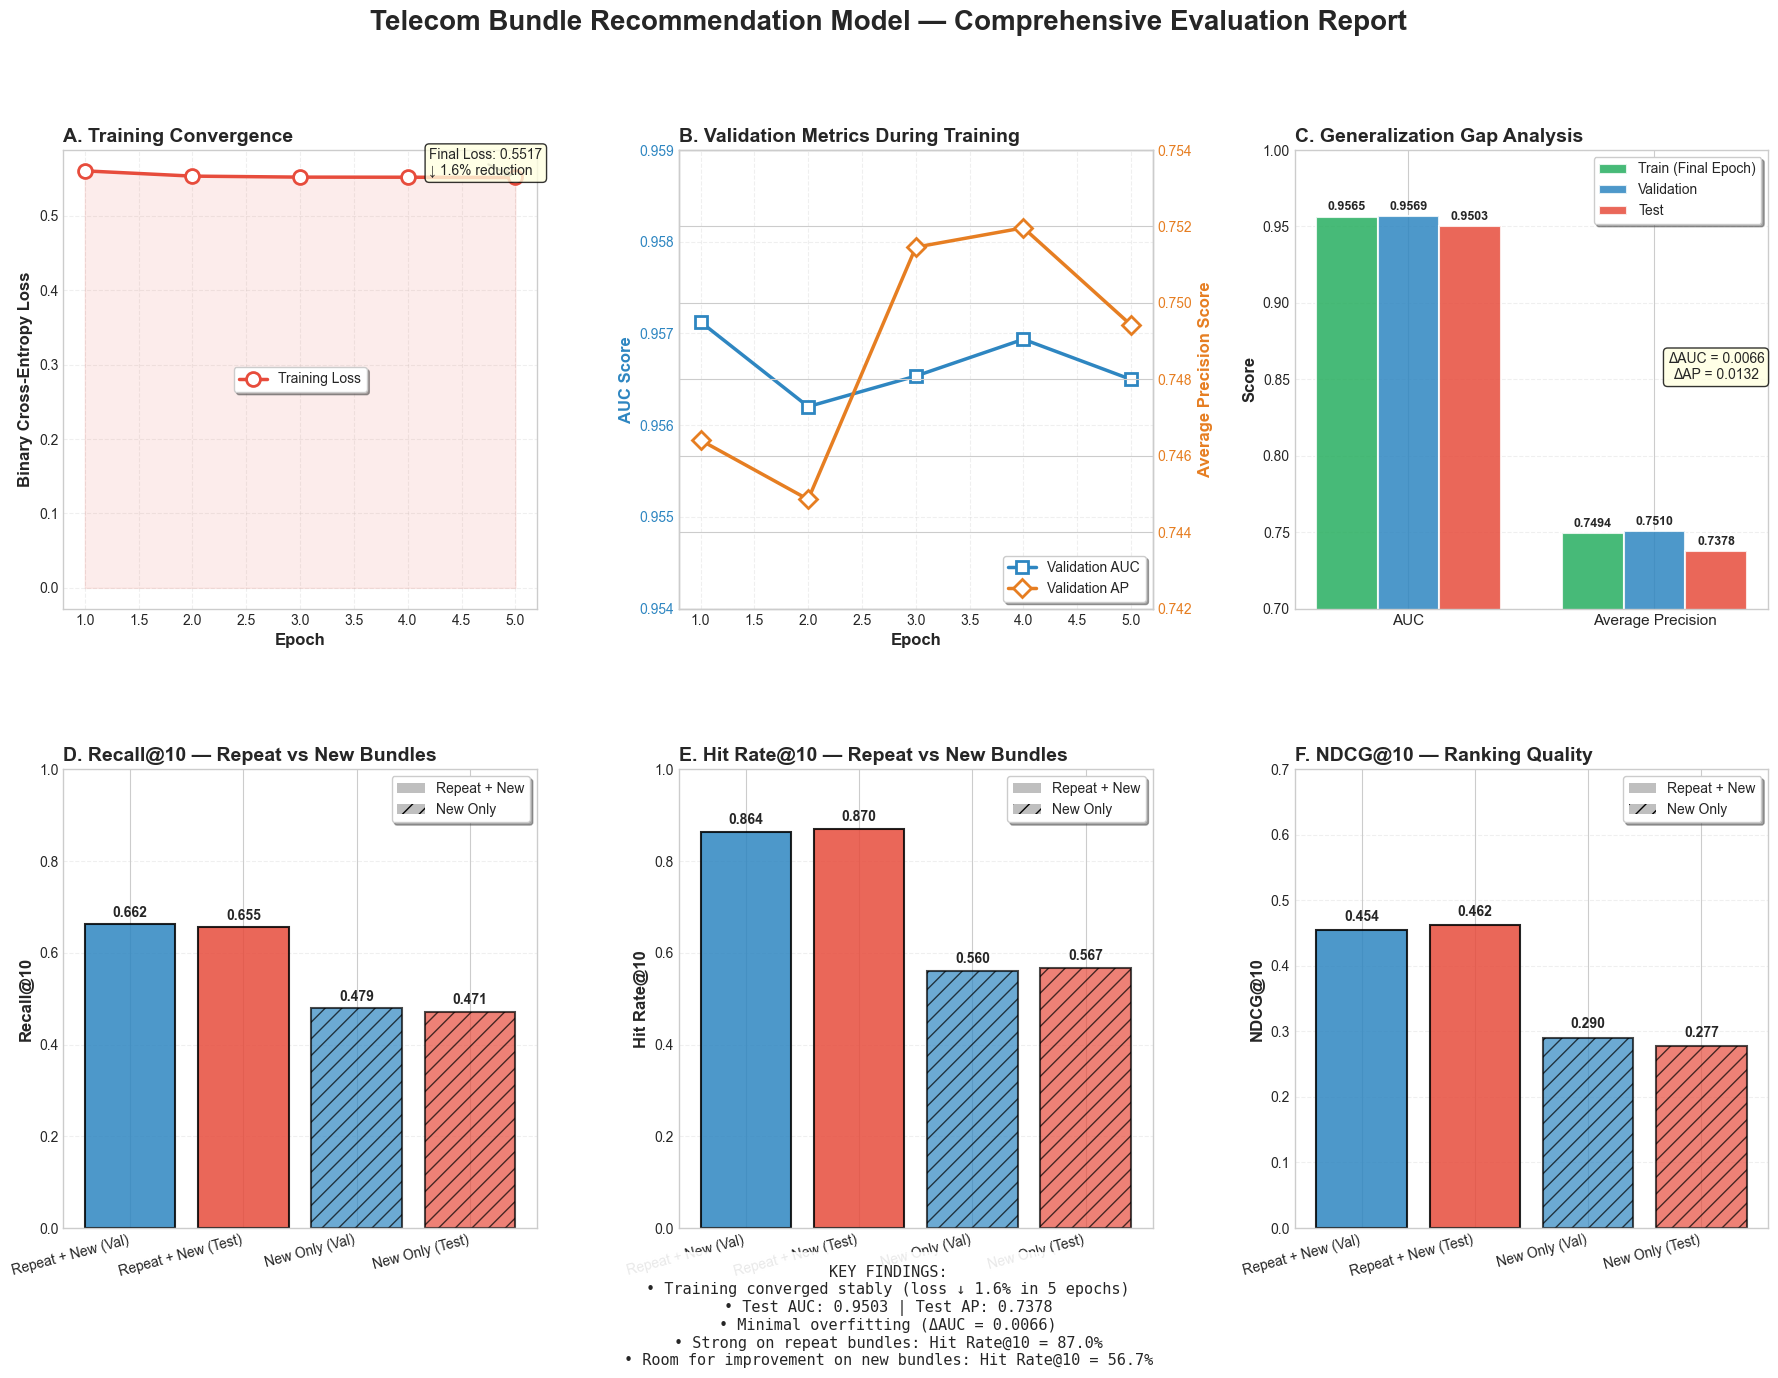

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")


# Training history
history = pd.DataFrame({
    'epoch': [1, 2, 3, 4, 5],
    'train_loss': [0.560605, 0.553511, 0.552169, 0.552033, 0.551721],
    'val_auc': [0.957127, 0.956203, 0.956536, 0.956937, 0.956499],
    'val_ap': [0.746410, 0.744859, 0.751458, 0.751964, 0.749421]
}).set_index('epoch')

# Final evaluation metrics
val_auc = 0.956899
val_ap = 0.750969
test_auc = 0.950304
test_ap = 0.737765

# Top-K metrics
topk_metrics = {
    'Repeat + New (Val)': val_topk_all,
    'Repeat + New (Test)': test_topk_all,
    'New Only (Val)': val_topk_new,
    'New Only (Test)': test_topk_new
}

# ============================================================
# Main Visualization Figure
# ============================================================
fig = plt.figure(figsize=(22, 14))
fig.suptitle('Telecom Bundle Recommendation Model — Comprehensive Evaluation Report',
             fontsize=20, fontweight='bold', y=0.98)

# Create a 2x3 grid layout
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.30)

# ============================================================
# Panel 1: Training Loss Curve
# ============================================================
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history.index, history['train_loss'], 
         marker='o', markersize=10, linewidth=2.5, 
         color='#E74C3C', markerfacecolor='white', 
         markeredgewidth=2, markeredgecolor='#E74C3C',
         label='Training Loss')
ax1.fill_between(history.index, history['train_loss'], 
                  alpha=0.1, color='#E74C3C')
ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Binary Cross-Entropy Loss', fontsize=12, fontweight='bold')
ax1.set_title('A. Training Convergence', fontsize=14, fontweight='bold', loc='left')
ax1.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='--')

# Annotate final loss
final_loss = history['train_loss'].iloc[-1]
loss_drop = (history['train_loss'].iloc[0] - final_loss) / history['train_loss'].iloc[0] * 100
ax1.annotate(f'Final Loss: {final_loss:.4f}\n↓ {loss_drop:.1f}% reduction',
             xy=(5, final_loss), xytext=(4.2, final_loss + 0.003),
             fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8),
             arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))


ax2 = fig.add_subplot(gs[0, 1])

# AUC on primary y-axis
color_auc = '#2E86C1'
ax2_auc = ax2
line1 = ax2_auc.plot(history.index, history['val_auc'], 
                      marker='s', markersize=9, linewidth=2.5,
                      color=color_auc, markerfacecolor='white',
                      markeredgewidth=2, markeredgecolor=color_auc,
                      label='Validation AUC')
ax2_auc.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2_auc.set_ylabel('AUC Score', fontsize=12, fontweight='bold', color=color_auc)
ax2_auc.tick_params(axis='y', labelcolor=color_auc)
ax2_auc.set_ylim(0.954, 0.959)

# AP on secondary y-axis
color_ap = '#E67E22'
ax2_ap = ax2_auc.twinx()
line2 = ax2_ap.plot(history.index, history['val_ap'], 
                     marker='D', markersize=9, linewidth=2.5,
                     color=color_ap, markerfacecolor='white',
                     markeredgewidth=2, markeredgecolor=color_ap,
                     label='Validation AP')
ax2_ap.set_ylabel('Average Precision Score', fontsize=12, fontweight='bold', color=color_ap)
ax2_ap.tick_params(axis='y', labelcolor=color_ap)
ax2_ap.set_ylim(0.742, 0.754)

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax2_auc.legend(lines, labels, fontsize=10, loc='lower right', 
               frameon=True, fancybox=True, shadow=True)

ax2_auc.set_title('B. Validation Metrics During Training', fontsize=14, fontweight='bold', loc='left')
ax2_auc.grid(True, alpha=0.3, linestyle='--')


ax3 = fig.add_subplot(gs[0, 2])

metrics_final = ['AUC', 'Average Precision']
train_values = [history['val_auc'].iloc[-1], history['val_ap'].iloc[-1]]
val_values = [val_auc, val_ap]
test_values = [test_auc, test_ap]

x = np.arange(len(metrics_final))
width = 0.25

bars1 = ax3.bar(x - width, train_values, width, label='Train (Final Epoch)',
                color='#27AE60', edgecolor='white', linewidth=1.5, alpha=0.85)
bars2 = ax3.bar(x, val_values, width, label='Validation',
                color='#2E86C1', edgecolor='white', linewidth=1.5, alpha=0.85)
bars3 = ax3.bar(x + width, test_values, width, label='Test',
                color='#E74C3C', edgecolor='white', linewidth=1.5, alpha=0.85)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                 f'{height:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax3.set_ylabel('Score', fontsize=12, fontweight='bold')
ax3.set_title('C. Generalization Gap Analysis', fontsize=14, fontweight='bold', loc='left')
ax3.set_xticks(x)
ax3.set_xticklabels(metrics_final, fontsize=11)
ax3.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)
ax3.set_ylim(0.70, 1.0)
ax3.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add generalization gap annotation
auc_gap = val_auc - test_auc
ap_gap = val_ap - test_ap
ax3.annotate(f'ΔAUC = {auc_gap:.4f}\nΔAP = {ap_gap:.4f}',
             xy=(1.25, 0.85), fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8),
             ha='center')


ax4 = fig.add_subplot(gs[1, 0])

categories = list(topk_metrics.keys())
recall_values = [topk_metrics[cat]['recall@10'] for cat in categories]
colors_recall = ['#2E86C1', '#E74C3C', '#2E86C1', '#E74C3C']
hatches = ['', '', '//', '//']

bars = ax4.bar(range(len(categories)), recall_values, color=colors_recall, 
               edgecolor='black', linewidth=1.5, alpha=0.85)

# Apply hatching for "New Only" bars
for i, (bar, hatch) in enumerate(zip(bars, hatches)):
    if hatch:
        bar.set_hatch(hatch)
        bar.set_alpha(0.7)

# Add value labels
for bar, val in zip(bars, recall_values):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax4.set_xticks(range(len(categories)))
ax4.set_xticklabels(categories, fontsize=10, rotation=15, ha='right')
ax4.set_ylabel('Recall@10', fontsize=12, fontweight='bold')
ax4.set_title('D. Recall@10 — Repeat vs New Bundles', fontsize=14, fontweight='bold', loc='left')
ax4.set_ylim(0, 1.0)
ax4.grid(True, alpha=0.3, linestyle='--', axis='y')

# Add legend for hatches
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', alpha=0.5, label='Repeat + New'),
                   Patch(facecolor='gray', alpha=0.5, hatch='//', label='New Only')]
ax4.legend(handles=legend_elements, fontsize=10, loc='upper right',
           frameon=True, fancybox=True, shadow=True)


ax5 = fig.add_subplot(gs[1, 1])

hitrate_values = [topk_metrics[cat]['hitrate@10'] for cat in categories]

bars = ax5.bar(range(len(categories)), hitrate_values, color=colors_recall,
               edgecolor='black', linewidth=1.5, alpha=0.85)

for i, (bar, hatch) in enumerate(zip(bars, hatches)):
    if hatch:
        bar.set_hatch(hatch)
        bar.set_alpha(0.7)

for bar, val in zip(bars, hitrate_values):
    ax5.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax5.set_xticks(range(len(categories)))
ax5.set_xticklabels(categories, fontsize=10, rotation=15, ha='right')
ax5.set_ylabel('Hit Rate@10', fontsize=12, fontweight='bold')
ax5.set_title('E. Hit Rate@10 — Repeat vs New Bundles', fontsize=14, fontweight='bold', loc='left')
ax5.set_ylim(0, 1.0)
ax5.grid(True, alpha=0.3, linestyle='--', axis='y')

legend_elements = [Patch(facecolor='gray', alpha=0.5, label='Repeat + New'),
                   Patch(facecolor='gray', alpha=0.5, hatch='//', label='New Only')]
ax5.legend(handles=legend_elements, fontsize=10, loc='upper right',
           frameon=True, fancybox=True, shadow=True)


ax6 = fig.add_subplot(gs[1, 2])

ndcg_values = [topk_metrics[cat]['ndcg@10'] for cat in categories]

bars = ax6.bar(range(len(categories)), ndcg_values, color=colors_recall,
               edgecolor='black', linewidth=1.5, alpha=0.85)

for i, (bar, hatch) in enumerate(zip(bars, hatches)):
    if hatch:
        bar.set_hatch(hatch)
        bar.set_alpha(0.7)

for bar, val in zip(bars, ndcg_values):
    ax6.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax6.set_xticks(range(len(categories)))
ax6.set_xticklabels(categories, fontsize=10, rotation=15, ha='right')
ax6.set_ylabel('NDCG@10', fontsize=12, fontweight='bold')
ax6.set_title('F. NDCG@10 — Ranking Quality', fontsize=14, fontweight='bold', loc='left')
ax6.set_ylim(0, 0.7)
ax6.grid(True, alpha=0.3, linestyle='--', axis='y')

legend_elements = [Patch(facecolor='gray', alpha=0.5, label='Repeat + New'),
                   Patch(facecolor='gray', alpha=0.5, hatch='//', label='New Only')]
ax6.legend(handles=legend_elements, fontsize=10, loc='upper right',
           frameon=True, fancybox=True, shadow=True)


summary_text = (
    "KEY FINDINGS:\n"
    "• Training converged stably (loss ↓ 1.6% in 5 epochs)\n"
    f"• Test AUC: {test_auc:.4f} | Test AP: {test_ap:.4f}\n"
    "• Minimal overfitting (ΔAUC = 0.0066)\n"
    f"• Strong on repeat bundles: Hit Rate@10 = {topk_metrics['Repeat + New (Test)']['hitrate@10']:.1%}\n"
    f"• Room for improvement on new bundles: Hit Rate@10 = {topk_metrics['New Only (Test)']['hitrate@10']:.1%}"
)

fig.text(0.5, 0.01, summary_text, ha='center', va='bottom',
         fontsize=11, fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='#2C3E50', 
                    edgecolor='#1A252F', alpha=0.9, color='white'))

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('telecom_bundle_model_evaluation.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()